<a id="1"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:center;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>✨ Predicting Car's Ex-Showroom Prices. ✨</b></div>

<h3 align="center" style="font-size: 35px; color: #800080; font-family: Georgia;">
    <span style="color: #008080;"> Author:</span> 
    <span style="color: black;">AGRIM AGARWAL .📄🖋️</span>
</h3>

<img src="https://miro.medium.com/v2/resize:fit:1200/0*Y7SWB-YvdAfsAUYZ.png" style='width: 1000px; height: 450px;'>

---

----

----

In [59]:
##IMPORT LIBRARY

In [298]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,PowerTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,r2_score

In [61]:
##LOAD DATASET

In [62]:
df = pd.read_csv(r"C:\Users\hp\Downloads\cars_engage_2022 (1).csv",index_col=[0])

In [63]:
df.head(3)

,Make,Model,Variant,Ex-Showroom_Price,Displacement,Cylinders,Valves_Per_Cylinder,Drivetrain,Cylinder_Configuration,Emission_Norm,...,Leather_Wrapped_Steering,Automatic_Headlamps,Engine_Type,ASR_/_Traction_Control,Cruise_Control,USB_Ports,Heads-Up_Display,Welcome_Lights,Battery,Electric_Range
0,Tata,Nano Genx,Xt,"Rs. 2,92,667",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Tata,Nano Genx,Xe,"Rs. 2,36,447",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Tata,Nano Genx,Emax Xm,"Rs. 2,96,661",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
##cheaking data dimension

In [65]:
df.shape

(1276, 140)

In [66]:
##cheaking dataset information

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1276 entries, 0 to 1275
Columns: 140 entries, Make to Electric_Range
dtypes: float64(6), object(134)
memory usage: 1.4+ MB


In [68]:
df.select_dtypes(include="float").sample(5)

,Cylinders,Valves_Per_Cylinder,Doors,Seating_Capacity,Number_of_Airbags,USB_Ports
1055,6.0,4.0,2.0,4.0,6.0,NaN
369,3.0,4.0,5.0,5.0,1.0,NaN
1230,4.0,4.0,4.0,5.0,7.0,NaN
344,8.0,4.0,2.0,2.0,4.0,NaN
79,3.0,4.0,5.0,7.0,2.0,NaN


In [69]:
df.select_dtypes(include="object").sample(5)

,Make,Model,Variant,Ex-Showroom_Price,Displacement,Drivetrain,Cylinder_Configuration,Emission_Norm,Engine_Location,Fuel_System,...,Paddle_Shifters,Leather_Wrapped_Steering,Automatic_Headlamps,Engine_Type,ASR_/_Traction_Control,Cruise_Control,Heads-Up_Display,Welcome_Lights,Battery,Electric_Range
307,NaN,Mercedes-Benz Gls,350 Cdi,"Rs. 88,20,000",2987 cc,AWD (All Wheel Drive),V,BS IV,"Front, Longitudinal",Injection,...,NaN,Yes,Yes,NaN,Yes,Yes,NaN,NaN,NaN,NaN
1010,Hyundai,Elantra,Sx,"Rs. 18,49,000",1999 cc,FWD (Front Wheel Drive),In-line,BS 6,"Front, Transverse",Injection,...,NaN,Yes,Yes,NaN,Yes,Yes,NaN,NaN,NaN,NaN
328,NaN,Mercedes-Benz G-Class,Amg G 63,"Rs. 2,18,75,136",3982 cc,AWD (All Wheel Drive),V,BS 6,"Front, Longitudinal",Injection,...,Yes,Yes,Yes,NaN,Yes,Yes,NaN,NaN,NaN,NaN
148,Volkswagen,Polo,Trendline 1.5L (D),"Rs. 7,34,500",1498 cc,FWD (Front Wheel Drive),In-line,BS IV,"Front, Transverse",Injection,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1115,Skoda,Rapid,Onyx Mt Diesel,"Rs. 11,58,599",1498 cc,FWD (Front Wheel Drive),In-line,BS IV,"Front, Transverse",Injection,...,NaN,Yes,NaN,NaN,NaN,Yes,NaN,NaN,NaN,NaN


In [70]:
##DATA CLEANING

In [71]:
null_df = df.isnull().sum()[df.isnull().sum()>0].to_frame().rename(columns={0:"Total No. of Missing Values"})
null_df["% of Missing values"] = round(100*null_df["Total No. of Missing Values"]/len(df),2)
print(null_df)

                     Total No. of Missing Values  % of Missing values
Make                                          75                 5.88
Displacement                                  12                 0.94
Cylinders                                     66                 5.17
Valves_Per_Cylinder                          102                 7.99
Drivetrain                                     7                 0.55
...                                          ...                  ...
USB_Ports                                   1247                97.73
Heads-Up_Display                            1225                96.00
Welcome_Lights                              1207                94.59
Battery                                     1263                98.98
Electric_Range                              1259                98.67

[134 rows x 2 columns]


In [72]:
##drop the columns having 60% missing value
high_null_df = null_df[null_df["% of Missing values"]>60].index.tolist()

df.drop(columns=high_null_df,inplace=True)
df.shape

(1276, 108)

In [73]:
df.dtypes.to_frame().rename(columns={0:"Data-Types"})

,Data-Types
Make,object
Model,object
Variant,object
Ex-Showroom_Price,object
Displacement,object
...,...
Cooled_Glove_Box,object
Turbocharger,object
ISOFIX_(Child-Seat_Mount),object
Leather_Wrapped_Steering,object


In [74]:
df_numeric = df.select_dtypes(include="float")    
df_object  = df.select_dtypes(include="object")  

In [75]:
print("Shape of numerical dataframe is:",df_numeric.shape)
print("Shape of categorical dataframe is:", df_object.shape)

Shape of numerical dataframe is: (1276, 5)
Shape of categorical dataframe is: (1276, 103)


In [76]:
df_numeric.sample(2)

,Cylinders,Valves_Per_Cylinder,Doors,Seating_Capacity,Number_of_Airbags
721,6.0,4.0,5.0,5.0,6.0
410,3.0,4.0,5.0,5.0,2.0


In [77]:
null_df = df_numeric.isnull().sum().to_frame().rename(columns={0:"Total No. of Missing Values"})
null_df["% of Missing Values"] = round((100*null_df["Total No. of Missing Values"])/len(df_numeric),2)
print(null_df)

                     Total No. of Missing Values  % of Missing Values
Cylinders                                     66                 5.17
Valves_Per_Cylinder                          102                 7.99
Doors                                          4                 0.31
Seating_Capacity                               6                 0.47
Number_of_Airbags                            135                10.58


In [78]:
imputer = SimpleImputer(strategy="median")

In [79]:
cols = df_numeric.columns.to_list()     

df_numeric[cols] = imputer.fit_transform(df[cols])

In [80]:
df_numeric.isnull().sum().to_frame().rename(columns={0:"Total No. of Missing Values Left"})

,Total No. of Missing Values Left
Cylinders,0
Valves_Per_Cylinder,0
Doors,0
Seating_Capacity,0
Number_of_Airbags,0


In [81]:
df_object.sample(3)

,Make,Model,Variant,Ex-Showroom_Price,Displacement,Drivetrain,Cylinder_Configuration,Emission_Norm,Engine_Location,Fuel_System,...,Seat_Height_Adjustment,Navigation_System,Second_Row_AC_Vents,Rear_Center_Armrest,iPod_Compatibility,Cooled_Glove_Box,Turbocharger,ISOFIX_(Child-Seat_Mount),Leather_Wrapped_Steering,Cruise_Control
771,Mini,Cooper 3 Door,Cooper D,"Rs. 29,90,000",1496 cc,FWD (Front Wheel Drive),In-line,BS IV,"Front, Longitudinal",Injection,...,Electric Adjustment,NaN,NaN,NaN,NaN,NaN,Yes,NaN,Yes,NaN
364,Maruti Suzuki,Alto,Lxi Cng (Cng +,"Rs. 4,05,570",796 cc,FWD (Front Wheel Drive),In-line,BS 6,"Front, Transverse",Injection,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
698,Toyota,Innova Crysta,2.4 Vx 7 Str,"Rs. 19,27,000",2393 cc,RWD (Rear Wheel Drive),In-line,BS IV,"Front, Longitudinal",Injection,...,Manual Adjustment,Yes,Yes,Cup Holders,Yes,Yes,Yes,Yes,Yes,NaN


In [86]:
relevant_cols = ['Make', 'Model', 'Variant', 'Ex-Showroom_Price', 'Displacement', 'Drivetrain',"Cylinder_Configuration",
                 'Emission_Norm', "Engine_Location", "Fuel_Tank_Capacity","Height", "Length", "Width",
                 "Body_Type", "ARAI_Certified_Mileage", "Kerb_Weight", "Ground_Clearance", "Boot_Space", "Power_Steering",
                 "Keyless_Entry", "Power", "Torque", "Odometer", "Speedometer", "Tachometer", "Tripmeter", "Seats_Material"
                 ,"Fuel_Type", "Wheelbase", "Central_Locking", "Child_Safety_Locks", "Low_Fuel_Warning",
                 "Third_Row_AC_Vents", "Second_Row_AC_Vents", "Auto-Dimming_Rear-View_Mirror", "Engine_Immobilizer",
                 "ABS_(Anti-lock_Braking_System)", "EBD_(Electronic_Brake-force_Distribution)", "Cooled_Glove_Box",
                 "EBA_(Electronic_Brake_Assist)",
                 "Gear_Shift_Reminder", "Adjustable_Steering_Column", "Parking_Assistance","Key_Off_Reminder",
                 "USB_Compatibility", "Bluetooth", "Seat_Height_Adjustment", "Navigation_System", "Turbocharger",
                 "Cruise_Control"]

In [87]:
print(df_object.columns.tolist())

['Make', 'Model', 'Variant', 'Ex-Showroom_Price', 'Displacement', 'Drivetrain', 'Cylinder_Configuration', 'Emission_Norm', 'Engine_Location', 'Fuel_System', 'Fuel_Tank_Capacity', 'Fuel_Type', 'Height', 'Length', 'Width', 'Body_Type', 'City_Mileage', 'ARAI_Certified_Mileage', 'Kerb_Weight', 'Gears', 'Ground_Clearance', 'Front_Brakes', 'Rear_Brakes', 'Front_Suspension', 'Rear_Suspension', 'Front_Track', 'Rear_Track', 'Front_Tyre_&_Rim', 'Rear_Tyre_&_Rim', 'Power_Steering', 'Power_Windows', 'Keyless_Entry', 'Power', 'Torque', 'Odometer', 'Speedometer', 'Tachometer', 'Tripmeter', 'Seats_Material', 'Type', 'Wheelbase', 'Wheels_Size', 'Start_/_Stop_Button', '12v_Power_Outlet', 'Audiosystem', 'Aux-in_Compatibility', 'Average_Fuel_Consumption', 'Basic_Warranty', 'Bluetooth', 'Boot-lid_Opener', 'Boot_Space', 'CD_/_MP3_/_DVD_Player', 'Central_Locking', 'Child_Safety_Locks', 'Clock', 'Cup_Holders', 'Distance_to_Empty', 'Door_Pockets', 'Engine_Malfunction_Light', 'Extended_Warranty', 'FM_Radio', '

In [88]:
df_object_2 = df_object[relevant_cols]

df_object_2.shape

(1276, 50)

In [89]:
df_object_2.sample(2)

,Make,Model,Variant,Ex-Showroom_Price,Displacement,Drivetrain,Cylinder_Configuration,Emission_Norm,Engine_Location,Fuel_Tank_Capacity,...,Gear_Shift_Reminder,Adjustable_Steering_Column,Parking_Assistance,Key_Off_Reminder,USB_Compatibility,Bluetooth,Seat_Height_Adjustment,Navigation_System,Turbocharger,Cruise_Control
152,Volkswagen,Polo,Gt Tdi,"Rs. 9,88,500",1498 cc,FWD (Front Wheel Drive),In-line,BS IV,"Front, Transverse",45 litres,...,NaN,"Rake, Reach",Rear sensors,Yes,Yes,Yes,Manual Adjustment,NaN,Yes,Yes
159,Maruti Suzuki,Dzire,Zdi Amt,"Rs. 8,63,122",1248 cc,FWD (Front Wheel Drive),In-line,BS IV,"Front, Transverse",37 litres,...,NaN,Rake,Rear sensors,Yes,Yes,Yes,Manual Adjustment,NaN,Yes,NaN


In [90]:
null_df = df_object_2.isnull().sum()[df_object_2.isnull().sum()>0].to_frame().rename(columns={0:"Total No. of Missing Values"})
null_df["% of Missing Values"] = round((100*null_df["Total No. of Missing Values"])/len(df_object_2),2)
null_df.sort_values(by="% of Missing Values",ascending=False)

,Total No. of Missing Values,% of Missing Values
Cruise_Control,727,56.97
EBA_(Electronic_Brake_Assist),690,54.08
Cooled_Glove_Box,645,50.55
Auto-Dimming_Rear-View_Mirror,620,48.59
Turbocharger,618,48.43
Second_Row_AC_Vents,602,47.18
Navigation_System,593,46.47
Gear_Shift_Reminder,543,42.55
Third_Row_AC_Vents,366,28.68
Kerb_Weight,365,28.61


In [91]:
print("Unique Values in Make column are:\n")
print(df_object_2["Make"].unique())

Unique Values in Make column are:

['Tata' 'Datsun' 'Renault' 'Maruti Suzuki' 'Hyundai' 'Premier' 'Toyota'
 'Nissan' 'Volkswagen' 'Ford' 'Mahindra' 'Fiat' 'Honda' 'Jeep' 'Isuzu'
 'Skoda' 'Audi' nan 'Dc' 'Mini' 'Volvo' 'Jaguar' 'Bmw' 'Land Rover'
 'Porsche' 'Lexus' 'Maserati' 'Lamborghini' 'Bentley' 'Ferrari'
 'Aston Martin' 'Bugatti' 'Bajaj' 'Icml' 'Force' 'Mg' 'Kia'
 'Land Rover Rover' 'Mitsubishi' 'Maruti Suzuki R']


In [92]:
df_object_2[df_object_2["Make"]=="Land Rover Rover"][["Make","Model"]]

,Make,Model
789,Land Rover Rover,Range Evoque
790,Land Rover Rover,Range Evoque
791,Land Rover Rover,Range Evoque
792,Land Rover Rover,Range Evoque
818,Land Rover Rover,Range Evoque Convertible
819,Land Rover Rover,Range Velar
820,Land Rover Rover,Range Velar
827,Land Rover Rover,Range Sport
828,Land Rover Rover,Range Sport
829,Land Rover Rover,Range Sport


In [93]:
df_object_2["Make"] = df_object_2["Make"].replace({"Land Rover Rover":"Land Rover"})

In [94]:
df_object_2["Model"] = df_object_2["Model"].str.replace("Range","Range Rover")

In [95]:
df_object_2[df_object_2["Make"]=="Maruti Suzuki R"][["Make","Model"]]

,Make,Model
1173,Maruti Suzuki R,Wagon
1174,Maruti Suzuki R,Wagon
1175,Maruti Suzuki R,Wagon
1176,Maruti Suzuki R,Wagon
1177,Maruti Suzuki R,Wagon
1178,Maruti Suzuki R,Wagon
1179,Maruti Suzuki R,Wagon
1180,Maruti Suzuki R,Wagon
1181,Maruti Suzuki R,Wagon
1182,Maruti Suzuki R,Wagon


In [96]:
df_object_2["Make"] = df_object_2["Make"].replace({"Maruti Suzuki R":"Maruti Suzuki"})
df_object_2["Model"] = df_object_2["Model"].replace({"Wagon":"Wagon R"})

In [101]:
print("Total Missing values in Make Attribute is:",df_object_2["Make"].isnull().sum())

Total Missing values in Make Attribute is: 0


In [102]:
df_object_2[df_object_2["Make"].isnull()][["Make","Model"]]

,Make,Model


In [103]:
##This will return all the index wherever there us a missing value.

index_list = df_object_2[df_object_2["Make"].isnull()].index   

for index in index_list:
    if df_object_2["Model"][index]=="Go+":
        df_object_2.loc[index,"Model"] = "Datsun Go+"
        
    value1 = df_object_2["Model"][index]
    value2 = value1.split(" ")[0]
    value3 = value1.split(" ")[1]
    
    df_object_2.loc[index, "Make"] = value2
    df_object_2.loc[index, "Model"] = value3

In [104]:
df_object_2.rename(columns={"Make":"Car Manufacturer", "Model":"Car Model"},inplace=True)

In [105]:
print("Total Missing values in Make Attribute is:",df_object_2["Car Manufacturer"].isnull().sum())

Total Missing values in Make Attribute is: 0


In [106]:
df_object_2["Ex-Showroom_Price"].sample(5).to_frame()

,Ex-Showroom_Price
14,"Rs. 3,83,290"
1163,"Rs. 2,21,55,390"
500,"Rs. 9,83,000"
570,"Rs. 12,49,990"
1150,"Rs. 38,64,000"


In [107]:
df_object_2["Ex-Showroom_Price"] = df_object_2["Ex-Showroom_Price"].str.replace("Rs. ","").str.replace(",","")

In [108]:
df_object_2["Ex-Showroom_Price"].sample(5).to_frame()

,Ex-Showroom_Price
874,42000000
19,484490
811,11000000
806,6426497
199,828600


In [109]:
df_object_2["Ex-Showroom_Price"] = df_object_2["Ex-Showroom_Price"].astype(int)

In [110]:
print("Total Missing value in Ex-Showroom Price Attribute is:",df_object_2["Ex-Showroom_Price"].isnull().sum())

Total Missing value in Ex-Showroom Price Attribute is: 0


In [111]:
df_object_2["Displacement"].sample(5).to_frame()

,Displacement
129,1197 cc
670,2179 cc
554,1497 cc
1018,1999 cc
446,1994 cc


In [112]:
df_object_2["Displacement"] = df["Displacement"].str.replace(" cc","")

In [113]:
df_object_2["Displacement"] = df_object_2["Displacement"].astype(float)

In [114]:
print("Total Missing Value in Dispalcement Attribute is:",df_object_2["Displacement"].isnull().sum())

Total Missing Value in Dispalcement Attribute is: 12


In [115]:
#The below code will return medain displacemnt value of each car manufacturer.
median_value = df_object_2.groupby(["Car Manufacturer"])["Displacement"].median().to_frame()

#The below code will return the index of NaN values present in Displacement Attribute.
index_list = df_object_2[df_object_2["Displacement"].isnull()].index


for index in index_list:
    manufacturer = df_object_2["Car Manufacturer"][index]    
    value = median_value["Displacement"][manufacturer]
    
    df_object_2.loc[index,"Displacement"] = value

In [116]:
print("Total Missing Values left in Displacemnt is:",df_object_2["Displacement"].isnull().sum())

Total Missing Values left in Displacemnt is: 0


In [117]:
df_object_2["Power"].sample(5).to_frame()

,Power
958,90PS@4000rpm
924,86Ps@3750rpm
322,258PS@3600rpm
6,54PS@5678rpm
840,340bhp@6400RPM


In [118]:
print("Total Missing Values is:",df_object_2["Power"].isnull().sum())

Total Missing Values is: 0


In [119]:
df_object_2["Power"].unique()

array(['38PS@5500rpm', '54PS@5678rpm', '68PS@5500rpm', '73PS@6000rpm',
       '74PS@6000RPM', '62PS@6000rpm', '68PS@6000rpm', '68PS@6200rpm',
       '59PS@6000rpm', '68PS@5000rpm', '78PS@5000rpm', '59bhp@6000rpm',
       '69PS@5500rpm', '59PS@5500RPM', '86PS@6000rpm', '83PS@6000rpm',
       '72PS@62050rpm', '76.6PS@5800rpm', '64PS@4000rpm', '72PS@4000rpm',
       '80PS@5600rpm', '68PS@3800rpm', '75PS@4000rpm', '90PS@5000rpm',
       '81.8bhp@6000rpm', '70bhp@4000RPM', '71PS@4000rpm',
       '69bhp@6000rpm', '84PS@6000rpm', '90PS@4000rpm', '69PS@6000rpm',
       '100PS@6000rpm', '76PS@6200RPM', '90PS@4200rpm', '105PS@5000rpm',
       '110PS@4400rpm', '84.3PS@6000rpm', '100PS@3750RPM', '96PS@6500rpm',
       '100PS@3700RPM', '96PS@6300rpm', '90PS@5600rpm', '65PS@4000rpm',
       '93PS@4000RPM', '140ps@5500rpm', '89PS@6000 rpm', '82PS@6000 rpm',
       '90PS@6000rpm', '100PS@3600rpm', '89 bhp@6000rpm', '173PS@3750rpm',
       '177PS@3600rpm', '178bhp@400rpm', '178Bhp @ 4000', '141PS@4000r

In [120]:
df_object_2[(df_object_2["Power"]=="1600Nm@2000-6000rpm")][["Power","Torque"]]

,Power,Torque
356,1600Nm@2000-6000rpm,1479bhp@6700rpm


In [121]:
df_object_2.loc[356,"Power"]="1479bhp@6700rpm"
df_object_2.loc[356,"Torque"]="1600Nm@2000-6000rpm"

In [122]:
new_power = []     

for i in df_object_2["Power"]:
    power_value = i.split("@")[0].replace(" ","").lower() 

    if "ps" in power_value:
        value1 = round((float(power_value.replace("ps",""))*0.98632),2)
        new_power.append(value1)
    
    elif "bhp" in power_value:
        value2 = round((float(power_value.replace("bhp",""))*1.01387),2)
        new_power.append(value2)
    
    elif "hp" in power_value:
        value3 = float(power_value.replace("hp",""))
        new_power.append(value3)
    
    elif "kw" in power_value:
        value4 = round((float(power_value.replace("kw",""))*1.34),2)
        new_power.append(value4)
    else:
        new_power.append(power_value)

In [123]:
df_object_2["Power"] = new_power

In [124]:
df_object_2["Power"] = df_object_2["Power"].astype(float)

In [125]:
df_object_2.rename(columns={"Power":"Power (HP)"},inplace=True)

In [126]:
df_object_2["Torque"].sample(5).to_frame()

,Torque
984,250Nm@1500-2750rpm
736,173Nm@4000rpm
940,200Nm@1750rpm
731,350Nm@1750-2500rpm
651,300Nm@1750-2500rpm


In [127]:
print("Total Missing values is:",df_object_2["Torque"].isnull().sum())

Total Missing values is: 2


In [128]:
df_object_2[df_object_2["Torque"].isnull()][["Car Manufacturer","Car Model","Variant","Torque"]]

,Car Manufacturer,Car Model,Variant,Torque
536,Mahindra,Bolero Power Plus,Plus Ac Bs4 Ps,NaN
1158,Bmw,6-Series,630I Gt Luxury Line,NaN


In [129]:
df_object_2[(df_object_2.index==535) | (df_object_2.index==1157) ][["Car Manufacturer","Car Model","Torque"]]

,Car Manufacturer,Car Model,Torque
535,Mahindra,Bolero Power Plus,195Nm@1400-2200rpm
1157,Bmw,6-Series,620Nm@2000-2500RPM


In [130]:
df_object_2.loc[536,"Torque"] = "195Nm@1400-2200rpm"
df_object_2.loc[1158,"Torque"] = "620Nm@2000-2500RPM"

In [131]:
df_object_2["Torque"].unique()

array(['51Nm@4000rpm', '72Nm@4386rpm', '91Nm@4250RPM', '101Nm@3000rpm',
       '85Nm@3000rpm', '90Nm@3500rpm', '78Nm@3500rpm', '104Nm@4000rpm',
       '99.04nm@4500RPM', '10.1kgm@4500RPM', '8.3KGM@4500rpm',
       '114NM@3300rpm', '113Nm@4200RPM', '96Nm@3500rpm',
       '103.9Nm@3500-4250rpm', '152Nm@2500RPM', '152Nm@2250RPM',
       '183Nm@1800-2400rpm', '104Nm@3100rpm', '170Nm@1800-2400rpm',
       '190Nm@1750-3000rpm', '140Nm@1500-4000rpm', '114Nm@6000rpm',
       '190Nm@2000rpm', '115Nm@4000rpm', '220Nm@1500rpm', '114Nm@4000rpm',
       '220Nm@1500-2750rpm', '95Nm@4000rpm', '172Nm@1500-4000rpm',
       '190NM@1750-2250RPM', '95Nm@3000-4300rpm', '230Nm@1500-2500rpm',
       '175Nm@1500-4100rpm', '250Nm@1500-2500rpm', '215Nm@1750-3000RPM',
       '120Nm@4250rpm', '132Nm@3000rpm', '160Nm@2000rpm', '209Nm@2000rpm',
       '210Nm@2000-4000RPM', '113Nm@4400 rpm', '113Nm@4200 rpm',
       '110Nm@4800rpm', '200Nm@1750rpm', '110 Nm@4800rpm',
       '350Nm@1750-2500rpm', '380Nm@1800-2800rpm'

In [132]:
new_torque = []

for i in df_object_2["Torque"]:
    torque_value = i.split("@")[0].replace(" ","").lower()
    
    if "nm" in torque_value:
        value1 = float(torque_value.replace("nm",""))
        new_torque.append(value1)
    
    elif "kgm" in torque_value:
        value2 = round((float(torque_value.replace("kgm",""))*9.80665),2)
        new_torque.append(value2)
    else:
        if "hp" in torque_value:
            new_torque.append(torque_value[:-2])
        else:
            new_torque.append(torque_value)

In [133]:
df_object_2["Torque"] = new_torque

In [134]:
df_object_2["Torque"] = df_object_2["Torque"].astype(float)

In [135]:
df_object_2.rename(columns={"Torque":"Torque (Nm)"},inplace=True)

In [136]:
df_object_2["ARAI_Certified_Mileage"].sample(5).to_frame()

,ARAI_Certified_Mileage
1078,25.4 km/litre
912,21.04 km/litre
603,16.09 km/litre
535,16.5 km/litre
672,16 km/litre


In [137]:
df_object_2["ARAI_Certified_Mileage"].unique()

array(['23.6 km/litre', nan, '21.9 km/litre', '25.17 km/litre',
       '22.5 km/litre', '23 km/litre', '23.01 km/litre', '24.04 km/litre',
       '15 km/litre', '24.07 km/litre', '20.1 km/litre', '23.1 km/litre',
       '20.3 km/litre', '24 km/litre', '20.89 km/litre', '20.5 km/litre',
       '16 km/litre', '23.7 km/litre', '18.16 km/litre', '23.59 km/litre',
       '18.97 km/litre', '19.49 km/litre', '22.95 km/litre',
       '17.57 km/litre', '15.7 km/litre', '20.14 km/litre', '20 km/litre',
       '28.4 km/litre', '22 km/litre', '18.6 km/litre', '22.54 km/litre',
       '18.15 km/litre', '25.35 km/litre', '20.4 km/litre',
       '25.4 km/litre', '18.78 km/litre', '17.21 km/litre',
       '19.91 km/litre', '24.4 km/litre', '19 km/litre', '21.66 km/litre',
       '21.73 km/litre', '26.1 km/litre', '19.4 km/litre',
       '16.78 km/litre', '17.71 km/litre', '20.08 km/litre',
       '17.1 km/litre', '23.87 km/litre', '21.01 km/litre',
       '19.56 km/litre', '18.2 km/litre', '27.3 km/li

In [138]:
new_mileage = []

for i in df_object_2["ARAI_Certified_Mileage"]:
    if type(i) == float:
        new_mileage.append(i)
    
    else:
        value = i.lower().split("km")[0].split("-")[0].strip()
        new_mileage.append(float(value))

In [139]:
df_object_2["ARAI_Certified_Mileage"] = new_mileage

In [140]:
print("Total Missing values is:",df_object_2["ARAI_Certified_Mileage"].isnull().sum())

Total Missing values is: 114


In [141]:
mean_values = df_object_2.groupby(["Car Manufacturer"])["ARAI_Certified_Mileage"].mean().to_frame()

index_list = df_object_2[df_object_2["ARAI_Certified_Mileage"].isnull()].index

for index in index_list:
    manufacturer = df_object_2["Car Manufacturer"][index]
    value = mean_values["ARAI_Certified_Mileage"][manufacturer]
    df_object_2.loc[index,"ARAI_Certified_Mileage"] = value

In [143]:
print("Missing Values left in ARAI_Certified_Mileage is:",df_object_2["ARAI_Certified_Mileage"].isnull().sum() )

Missing Values left in ARAI_Certified_Mileage is: 0


In [144]:
df_object_2[["Ground_Clearance","Boot_Space"]].sample(5)

,Ground_Clearance,Boot_Space
653,NaN,NaN
1057,108 mm,300 litres
1245,155 mm,590 litres
201,170 mm,592 litres
661,NaN,NaN


In [145]:
df_object_2["Ground_Clearance"].unique()

array(['180 mm', '185 mm', '184 mm', '160 mm', '165 mm', nan, '170 mm',
       '182 mm', '200 mm', '154 mm', '163 mm', '190 mm', '174 mm',
       '172 mm', '205 mm', '220 mm', '149 mm', '198 mm', '208 mm',
       '164 mm', '161 mm', '211 mm', '146 mm', '125 mm', '100 mm',
       '212 mm', '167 mm', '152 mm', '137 mm', '206 mm', '210 mm',
       '307 mm', '140 mm', '109 mm', '241 mm', '215 mm', '110 mm',
       '142 mm', '119 mm', '130 mm', '113 mm', '150 mm', '175 mm',
       '209 mm', '195 mm', '133 mm', '225 mm', '188 mm', '179 mm',
       '136 mm', '157 mm', '201 mm', '155 mm', '498 mm', '218 mm',
       '238 mm', '295.5 mm', '227 mm', '295 mm', '128 mm', '135 mm',
       '186 mm', '192 mm', '132 mm', '112 mm', '213 mm', '121 mm',
       '122 mm', '108 mm', '183 mm', '158 mm', '124 mm', '138 mm',
       '235 mm'], dtype=object)

In [146]:
new_values = []

for i in df_object_2["Ground_Clearance"]:
    if type(i)==float:
        new_values.append(i)
    else:
        value = i.lower().split("mm")[0].strip()
        new_values.append(float(value))

In [148]:
df_object_2["Ground_Clearance"] = new_values

In [149]:
print(df_object_2["Boot_Space"].unique().tolist())

['110 litres', '94 litres', '222 litres', '300 litres', '400 litres', '250 litres', '177 litres', '265 litres', '235 litres', nan, '242 litres', '240 litres', '260 litres', '625 litres', '454 litres', '251 litres', '210 litres', '407 litres', '320 litres', '316 litres', '285 litres', '280 litres', '378 litres', '257 litres', '330 litres', '592 litres', '339 litres', '354 litres', '438 litres', '615 litres', '522 litres', '150 litres', '425 litres', '488 litres', '470 litres', '460 litres', '278 litres', '215 litres', '432 litres', '360 litres', '480 litres', '455 litres', '505 litres', '520 litres', '560 litres', '550 litres', '650 litres', '1025 litres', '540 litres', '465 litres', '515 litres', '500 litres', '605 litres', '530 litres', '510 litres', '580 litres', '261 litres', '133 litres', '616 litres', '358 litres', '430 litres', '230 litres', '490 litres', '443 litres', '395 litres', '20 litres', '256 litres', '243 litres', '268 litres', '345 litres', '419 litres', '390 litres', '

In [150]:
new_values = []

for i in df_object_2["Boot_Space"]:
    if type(i) == float:
        new_values.append(i)
    else:
        value = i.lower().split("litres")[0][0:4].replace("(","")
        new_values.append(value)

In [151]:
df_object_2["Boot_Space"] = new_values

In [152]:
df_object_2[["Ground_Clearance","Boot_Space"]].isnull().sum().to_frame().rename(columns={0:"Total Missing values"})

,Total Missing values
Ground_Clearance,289
Boot_Space,249


In [153]:
ground_median = df_object_2.groupby(["Car Manufacturer"])["Ground_Clearance"].median().to_frame()

index_list = df_object_2[df_object_2["Ground_Clearance"].isnull()].index

for index in index_list:
    manufacturer = df_object_2["Car Manufacturer"][index]
    
    if manufacturer =="Lexus":
        df_object_2.loc[index, "Ground_Clearance"] = 160
    elif manufacturer =="Bugatti":
        df_object_2.loc[index,"Ground_Clearance"] = 105
    elif manufacturer =="Bajaj":
        df_object_2.loc[index,"Ground_Clearance"] = 180
    else:
        value  = ground_median["Ground_Clearance"][manufacturer]
        df_object_2.loc[index, "Ground_Clearance"] = value

In [154]:
# Remove leading/trailing spaces
df_object_2["Boot_Space"] = df_object_2["Boot_Space"].astype(str).str.strip()

# Convert to numeric
df_object_2["Boot_Space"] = pd.to_numeric(df_object_2["Boot_Space"], errors="coerce")

# Now calculate manufacturer-wise median
boot_median = df_object_2.groupby("Car Manufacturer")["Boot_Space"].median()

In [155]:
boot_median = df_object_2.groupby("Car Manufacturer")["Boot_Space"].median()

index_list = df_object_2[df_object_2["Boot_Space"].isnull()].index

for index in index_list:
    manufacturer = df_object_2.loc[index, "Car Manufacturer"]

    if manufacturer == "Dc":
        df_object_2.loc[index, "Boot_Space"] = 50

    elif manufacturer == "Bugatti":
        df_object_2.loc[index, "Boot_Space"] = 44

    elif manufacturer == "Icml":
        df_object_2.loc[index, "Boot_Space"] = 256

    elif manufacturer == "Force":
        df_object_2.loc[index, "Boot_Space"] = 500

    else:
        if manufacturer in boot_median.index:
            df_object_2.loc[index, "Boot_Space"] = boot_median[manufacturer]
        else:
            df_object_2.loc[index, "Boot_Space"] = df_object_2["Boot_Space"].median()

In [156]:
df_object_2["Ground_Clearance"] = df_object_2["Ground_Clearance"].astype(float)
df_object_2["Boot_Space"] = df_object_2["Boot_Space"].astype(float)


In [157]:
cols = ["Height","Length","Width","Wheelbase"]

df_object_2[cols].sample(5)

,Height,Length,Width,Wheelbase
594,1617 mm,3995 mm,1821 mm,2600 mm
60,1535 mm,3746 mm,1647 mm,2400 mm
559,1647 mm,3998 mm,1765 mm,2519 mm
914,1520 mm,3765 mm,1660 mm,2425 mm
346,1742 mm,5140 mm,1998 mm,2995 mm


In [158]:
for column in cols:
    df_object_2[column] = df_object_2[column].apply(lambda x: str(x).replace(" mm","").replace(".","")).astype(float)

In [159]:
df_object_2[cols].isnull().sum().to_frame().rename(columns={0:"Missing values"})

,Missing values
Height,1
Length,0
Width,12
Wheelbase,20


In [160]:
df_object_2[df_object_2["Height"].isnull()][["Car Manufacturer","Car Model","Height","Width","Wheelbase"]]

,Car Manufacturer,Car Model,Height,Width,Wheelbase
314,Audi,Rs5,NaN,NaN,NaN


In [161]:
df_object_2.loc[314,"Height"] = 1387.0
df_object_2.loc[314,"Width"] = 1866.0
df_object_2.loc[314,"Wheelbase"] = 2826.0

In [162]:
df_object_2[df_object_2["Width"].isnull()][["Car Manufacturer","Car Model","Height","Width"]]

,Car Manufacturer,Car Model,Height,Width
440,Icml,Extreme,1885.0,NaN
441,Icml,Extreme,1885.0,NaN
442,Icml,Extreme,1885.0,NaN
443,Icml,Extreme,1885.0,NaN
444,Icml,Extreme,1885.0,NaN
445,Icml,Extreme,1885.0,NaN
446,Icml,Extreme,1885.0,NaN
447,Icml,Extreme,1885.0,NaN
448,Icml,Extreme,1885.0,NaN
449,Icml,Extreme,1885.0,NaN


In [163]:
df_object_2["Width"] = df_object_2["Width"].replace(np.nan,1645.0)

In [164]:
wheelbase_median = df_object_2.groupby(["Car Manufacturer"])["Wheelbase"].median().to_frame()
index_list = df_object_2[df_object_2["Wheelbase"].isnull()].index

for index in index_list:
    manufacturer = df_object_2["Car Manufacturer"][index]
    value = wheelbase_median["Wheelbase"][manufacturer]
    df_object_2.loc[index,"Wheelbase"] = value

In [165]:
df_object_2[cols].isnull().sum().to_frame().rename(columns={0:"Missing values"})

,Missing values
Height,0
Length,0
Width,0
Wheelbase,0


In [166]:
cols = ["Fuel_Tank_Capacity","Kerb_Weight"]

df_object_2[cols].sample(5)

,Fuel_Tank_Capacity,Kerb_Weight
429,37 litres,985 kg
74,32 litres,825 kg
403,35 litres,NaN
230,40 litres,1064 kg
1022,66 litres,1550 kg


In [167]:
df_object_2["Fuel_Tank_Capacity"] = df_object_2["Fuel_Tank_Capacity"].apply(lambda x: str(x).split(" ")[0]).astype(float)
df_object_2["Kerb_Weight"] = df_object_2["Kerb_Weight"].apply(lambda x: str(x).split(" ")[0].split("-")[0]).astype(float)

In [168]:
df_object_2[cols].isnull().sum().to_frame().rename(columns={0:"Missing Values"})

,Missing Values
Fuel_Tank_Capacity,69
Kerb_Weight,365


In [169]:
median1 = df_object_2["Fuel_Tank_Capacity"].median()
median2 = df_object_2["Kerb_Weight"].median()

df_object_2["Fuel_Tank_Capacity"].fillna(value=median1, inplace=True)
df_object_2["Kerb_Weight"].fillna(value=median2, inplace=True)

In [170]:
cols = ["Odometer","Speedometer","Tachometer","Tripmeter"]

for column in cols:
    print(f"Unique values in {column} is:",df_object_2[column].unique().tolist())
    print("-"*120,"\n")

Unique values in Odometer is: ['Digital', 'Analog', nan, 'Digital, Analog', 'Yes']
------------------------------------------------------------------------------------------------------------------------ 

Unique values in Speedometer is: ['Analog', 'Digital', 'Analog, Digital', 'Digital, Analog', nan, 'Yes']
------------------------------------------------------------------------------------------------------------------------ 

Unique values in Tachometer is: ['Not on offer', 'Digital', 'Analog', 'Analog, Digital', 'Digital, Analog', 'Yes', nan, 'Analog, Not on offer']
------------------------------------------------------------------------------------------------------------------------ 

Unique values in Tripmeter is: ['Yes', '2', nan, '1', '1, 2']
------------------------------------------------------------------------------------------------------------------------ 



In [171]:
df_object_2["Speedometer"].replace({"Analog, Digital":"Digital, Analog"},inplace=True)
df_object_2["Tachometer"].replace({"Analog, Digital":"Digital, Analog","Analog, Not on offer":"Analog"},inplace=True)
df_object_2["Tripmeter"].replace({"1, 2":"Yes"},inplace=True)

In [172]:
df_object_2[cols].isnull().sum().to_frame().rename(columns={0:"Total Missing values"})

,Total Missing values
Odometer,43
Speedometer,45
Tachometer,13
Tripmeter,60


In [173]:
df_object_2[["Odometer","Speedometer"]] = df_object_2[["Odometer","Speedometer"]].fillna(value="Yes")
df_object_2[["Tachometer","Tripmeter"]] = df_object_2[["Tachometer","Tripmeter"]].fillna(value="Not Defiend")

In [174]:
df_object_2[cols].isnull().sum().to_frame().rename(columns={0:"Total Missing values"})

,Total Missing values
Odometer,0
Speedometer,0
Tachometer,0
Tripmeter,0


### 1. Computing the Missing Values.

In [175]:
df_object_2[["Variant","Drivetrain"]].isnull().sum().to_frame().rename(columns={0:"Missing values"})

,Missing values
Variant,0
Drivetrain,7


In [176]:
df_object_2[df_object_2["Drivetrain"].isnull()][["Car Manufacturer","Car Model","Drivetrain"]]

,Car Manufacturer,Car Model,Drivetrain
272,Mini,Clubman,NaN
303,Mercedes-Benz,E-Class,NaN
503,Tata,Nexon,NaN
843,Maserati,Ghibli,NaN
844,Maserati,Ghibli,NaN
845,Maserati,Ghibli,NaN
1162,Jaguar,F-Type,NaN


In [177]:
#The below code will return the index where there is a missing value in Drivetrain Attribute.
index_list = df_object_2[df_object_2["Drivetrain"].isnull()].index

for index in index_list:
    
    if df_object_2["Car Manufacturer"][index] in ["Mini","Maserati","Jaguar"]:
        df_object_2.loc[index,"Drivetrain"] = "AWD (All Wheel Drive)"
    
    elif df_object_2["Car Manufacturer"][index] == "Mercedes-Benz":
        df_object_2.loc[index,"Drivetrain"] = "RWD (Rear Wheel Drive)"
    
    elif df_object_2["Car Manufacturer"][index] == "Tata":
        df_object_2.loc[index,"Drivetrain"] = "FWD (Front Wheel Drive)"  

In [178]:
print("Missing Values lef in variant Attribute is:",df_object_2["Displacement"].isnull().sum())

Missing Values lef in variant Attribute is: 0


In [179]:
print(df_object_2["Drivetrain"].unique().tolist())

['RWD (Rear Wheel Drive)', 'FWD (Front Wheel Drive)', 'AWD (All Wheel Drive)', '4WD']


In [180]:
df_object_2["Drivetrain"] = df_object_2["Drivetrain"].replace({"RWD (Rear Wheel Drive)":"RWD",
                                                               "FWD (Front Wheel Drive)":"FWD",
                                                               "AWD (All Wheel Drive)":"AWD"})

In [181]:
df_object_2["Emission_Norm"].unique().tolist()

['BS IV', 'BS 6', nan, 'BS III', 'BS VI']

In [207]:
print("Total Missing Value in Emission Norm Attribute:",df_object_2["Emission_Norm"].isnull().sum())

Total Missing Value in Emission Norm Attribute: 11


In [182]:
df_object_2[df_object_2["Emission_Norm"].isnull()][["Car Manufacturer","Car Model","Emission_Norm"]]

,Car Manufacturer,Car Model,Emission_Norm
240,Mahindra,Alturas G4,NaN
243,Honda,Cr-V,NaN
347,Aston Martin,Db 11,NaN
687,Mahindra,E Verito,NaN
688,Mahindra,E Verito,NaN
689,Mahindra,E Verito,NaN
827,Land Rover,Range Rover Sport,NaN
833,Land Rover,Range Rover Sport,NaN
1145,Mitsubishi,Outlander,NaN
1162,Jaguar,F-Type,NaN


In [183]:
#filling value
#The below code will return the indexes where there is a NaN value in Emission Norm Attribute.
index_list = df_object_2[df_object_2["Emission_Norm"].isnull()].index

for index in index_list:
    
    if (df_object_2["Car Manufacturer"][index]=="Mahindra") & (df_object_2["Car Model"][index]=="Alturas G4"):
        df_object_2.loc[index,"Emission_Norm"] = "BS VI" 

    elif (df_object_2["Car Manufacturer"][index]=="Hyundai") & (df_object_2["Car Model"][index]=="Kona Electric"):
        df_object_2.loc[index,"Emission_Norm"] = "No Emissions"

    elif df_object_2["Car Manufacturer"][index] in ["Honda","Aston Martin","Land Rover","Jaguar"]:
        df_object_2.loc[index,"Emission_Norm"] = "BS VI"

    elif (df_object_2["Car Manufacturer"][index]=="Mahindra") & (df_object_2["Car Model"][index]=="E Verito"):
        df_object_2.loc[index,"Emission_Norm"] = "No Emissions"

    elif (df_object_2["Car Manufacturer"][index]=="Mitsubishi") & (df_object_2["Car Model"][index]=="Outlander"):
        df_object_2.loc[index,"Emission_Norm"] = "BS IV"

In [184]:
print("Total Missing Value left in Emission Norm Attribute:",df_object_2["Emission_Norm"].isnull().sum())

Total Missing Value left in Emission Norm Attribute: 0


In [185]:
cols = ["Cylinder_Configuration","Power_Steering","Keyless_Entry"]

df_object_2[cols].sample(5)

,Cylinder_Configuration,Power_Steering,Keyless_Entry
1081,In-line,Electric Power,Remote
1162,NaN,NaN,NaN
1111,In-line,Electro-Hydraulic,Remote
1180,In-line,Electric Power,NaN
1252,In-line,Electric Power,Smart Key


In [186]:
for column in cols:
    print(f"Unique Values in {column} is:")
    print(df_object_2[column].unique().tolist())
    print("-"*100)

Unique Values in Cylinder_Configuration is:
['In-line', 'V', 'Flat', 'W', nan]
----------------------------------------------------------------------------------------------------
Unique Values in Power_Steering is:
['Electric Power', nan, 'Yes', 'Hydraulic Power', 'Electric Power, Hydraulic Power', 'Electro-Hydraulic']
----------------------------------------------------------------------------------------------------
Unique Values in Keyless_Entry is:
['Remote', nan, 'Yes', 'Smart Key', 'Remote, Smart Key', 'Smart Key, Remote']
----------------------------------------------------------------------------------------------------


In [187]:
df_object_2["Power_Steering"] = df_object_2["Power_Steering"].replace("Electric Power, Hydraulic Power","Electro-Hydraulic")
df_object_2["Keyless_Entry"] = df_object_2["Keyless_Entry"].replace("Remote, Smart Key","Smart Key, Remote")

In [188]:
df_object_2[cols].isnull().sum().to_frame().rename(columns={0:"Missing values"})

,Missing values
Cylinder_Configuration,13
Power_Steering,57
Keyless_Entry,274


In [189]:
df_object_2[cols] = df_object_2[cols].fillna(value="Not Defined")

In [190]:
df_object_2[cols].isnull().sum().to_frame().rename(columns={0:"Missing values"})

,Missing values
Cylinder_Configuration,0
Power_Steering,0
Keyless_Entry,0


In [191]:
cols = ["Adjustable_Steering_Column","Body_Type","Parking_Assistance"]

for column in cols:
    print(f"Unique Values in {column} is:")
    print(df_object_2[column].unique().tolist())
    print("-"*100,"\n")

Unique Values in Adjustable_Steering_Column is:
[nan, 'Rake', 'Yes', 'Rake, Reach', 'Reach, Rake']
---------------------------------------------------------------------------------------------------- 

Unique Values in Body_Type is:
['Hatchback', 'MPV', 'MUV', 'SUV', 'Sedan', 'Crossover', nan, 'Coupe', 'Convertible', 'Sports, Hatchback', 'Sedan, Coupe', 'Sports', 'Crossover, SUV', 'SUV, Crossover', 'Sedan, Crossover', 'Sports, Convertible', 'Pick-up', 'Coupe, Convertible']
---------------------------------------------------------------------------------------------------- 

Unique Values in Parking_Assistance is:
[nan, 'Rear sensors', 'Rear sensors with camera', 'Front and rear sensors with camera', 'Rear sensors, Rear sensors with camera', 'Rear sensors with camera, Rear sensors', 'Yes', 'Front & rear sensors with 360 degree view', 'Front sensors, Rear sensors', 'Rear sensors, Front sensors', 'Front and rear sensors with camera, Front & rear sensors with 360 degree view']
------------

In [192]:
df_object_2["Adjustable_Steering_Column"].replace({"Rake, Reach":"Reach, Rake"},inplace=True)

df_object_2["Body_Type"] = df_object_2["Body_Type"].str.replace("Crossover, SUV","SUV, Crossover")

df_object_2["Parking_Assistance"].replace({"Front sensors, Rear sensors":"Rear sensors, Front sensors",
                                        "Rear sensors, Rear sensors with camera":"Rear sensors with camera, Rear sensors",
                                        "Front and rear sensors with camera, Front & rear sensors with 360 degree view":
                                          "Front & rear sensors with 360 degree view"},inplace=True)

In [193]:
df_object_2[cols].isnull().sum().to_frame().rename(columns={0:"Missing Values"})

,Missing Values
Adjustable_Steering_Column,191
Body_Type,6
Parking_Assistance,290


In [194]:
df_object_2[cols] = df_object_2[cols].fillna(value="Not Defined")

In [195]:
cols = ["Engine_Location","Seats_Material","Seat_Height_Adjustment"]

for column in cols:
    print(f"Unique values in {column} is:")
    print(df_object_2[column].unique().tolist())
    print("-"*120,"\n")

Unique values in Engine_Location is:
['Rear, Transverse', 'Front, Transverse', 'Front, Longitudinal', nan, 'Rear Mid, Transverse', 'Mid, Longitudinal', 'Mid, Transverse', 'Rear, Longitudinal']
------------------------------------------------------------------------------------------------------------------------ 

Unique values in Seats_Material is:
['Fabric', 'Leather', 'Polyurethene', nan, 'Vinyl']
------------------------------------------------------------------------------------------------------------------------ 

Unique values in Seat_Height_Adjustment is:
[nan, 'Manual Adjustment', 'Electric Adjustment with Memory', 'Electric Adjustment', 'Semi Automatic Adjustment']
------------------------------------------------------------------------------------------------------------------------ 



In [196]:
df_object_2[cols].isnull().sum().to_frame().rename(columns={0:"Missing values"})

,Missing values
Engine_Location,43
Seats_Material,12
Seat_Height_Adjustment,326


In [197]:
df_object_2[cols] = df_object_2[cols].fillna(value="Not Defiend")

In [198]:
cols = ['Central_Locking','Child_Safety_Locks','Low_Fuel_Warning','Third_Row_AC_Vents','Second_Row_AC_Vents',
        'Auto-Dimming_Rear-View_Mirror','Engine_Immobilizer','ABS_(Anti-lock_Braking_System)',
        'EBD_(Electronic_Brake-force_Distribution)','Cooled_Glove_Box','EBA_(Electronic_Brake_Assist)',
        'ESP_(Electronic_Stability_Program)','Gear_Shift_Reminder','Key_Off_Reminder','USB_Compatibility',
        'Bluetooth','Navigation_System','Turbocharger',"Automatic_Headlamps","Cruise_Control"]

In [203]:
missing_cols = [col for col in cols if col not in df_object_2.columns]
print(missing_cols)

['ESP_(Electronic_Stability_Program)', 'Automatic_Headlamps']


In [204]:
existing_cols = [col for col in cols if col in df_object_2.columns]

df_object_2[existing_cols] = df_object_2[existing_cols].fillna("Not Defined")

In [205]:
print(df_object_2.columns.tolist())

['Car Manufacturer', 'Car Model', 'Variant', 'Ex-Showroom_Price', 'Displacement', 'Drivetrain', 'Cylinder_Configuration', 'Emission_Norm', 'Engine_Location', 'Fuel_Tank_Capacity', 'Height', 'Length', 'Width', 'Body_Type', 'ARAI_Certified_Mileage', 'Kerb_Weight', 'Ground_Clearance', 'Boot_Space', 'Power_Steering', 'Keyless_Entry', 'Power (HP)', 'Torque (Nm)', 'Odometer', 'Speedometer', 'Tachometer', 'Tripmeter', 'Seats_Material', 'Fuel_Type', 'Wheelbase', 'Central_Locking', 'Child_Safety_Locks', 'Low_Fuel_Warning', 'Third_Row_AC_Vents', 'Second_Row_AC_Vents', 'Auto-Dimming_Rear-View_Mirror', 'Engine_Immobilizer', 'ABS_(Anti-lock_Braking_System)', 'EBD_(Electronic_Brake-force_Distribution)', 'Cooled_Glove_Box', 'EBA_(Electronic_Brake_Assist)', 'Gear_Shift_Reminder', 'Adjustable_Steering_Column', 'Parking_Assistance', 'Key_Off_Reminder', 'USB_Compatibility', 'Bluetooth', 'Seat_Height_Adjustment', 'Navigation_System', 'Turbocharger', 'Cruise_Control']


In [207]:
[col for col in df_object_2.columns if "ESP" in col]

[]

In [208]:
missing_cols = [col for col in cols if col not in df_object_2.columns]
print(missing_cols)

['ESP_(Electronic_Stability_Program)', 'Automatic_Headlamps']


In [210]:
object_cols = df_object_2.select_dtypes(include="object").columns

df_object_2[object_cols] = df_object_2[object_cols].fillna("Not Defined")

In [211]:
# joining both dataframe
df = pd.concat([df_numeric,df_object_2],axis=1)

In [212]:
df.shape

(1276, 55)

In [213]:
df.sample(3)

,Cylinders,Valves_Per_Cylinder,Doors,Seating_Capacity,Number_of_Airbags,Car Manufacturer,Car Model,Variant,Ex-Showroom_Price,Displacement,...,Gear_Shift_Reminder,Adjustable_Steering_Column,Parking_Assistance,Key_Off_Reminder,USB_Compatibility,Bluetooth,Seat_Height_Adjustment,Navigation_System,Turbocharger,Cruise_Control
1217,6.0,4.0,4.0,5.0,14.0,Lexus,Ls 500H,Ultra Luxury,18736000,3456.0,...,Yes,"Reach, Rake",Front & rear sensors with 360 degree view,Yes,Yes,Yes,Electric Adjustment,Yes,Not Defined,Yes
130,4.0,4.0,5.0,5.0,2.0,Hyundai,Elite I20,Sportz Plus Dual Tone,751693,1197.0,...,Yes,"Reach, Rake",Rear sensors with camera,Not Defined,Yes,Yes,Manual Adjustment,Not Defined,Not Defined,Not Defined
1231,4.0,4.0,4.0,5.0,7.0,Toyota,Yaris,V Cvt,1294000,1496.0,...,Yes,Rake,Front and rear sensors with camera,Yes,Yes,Yes,Manual Adjustment,Not Defined,Not Defined,Yes


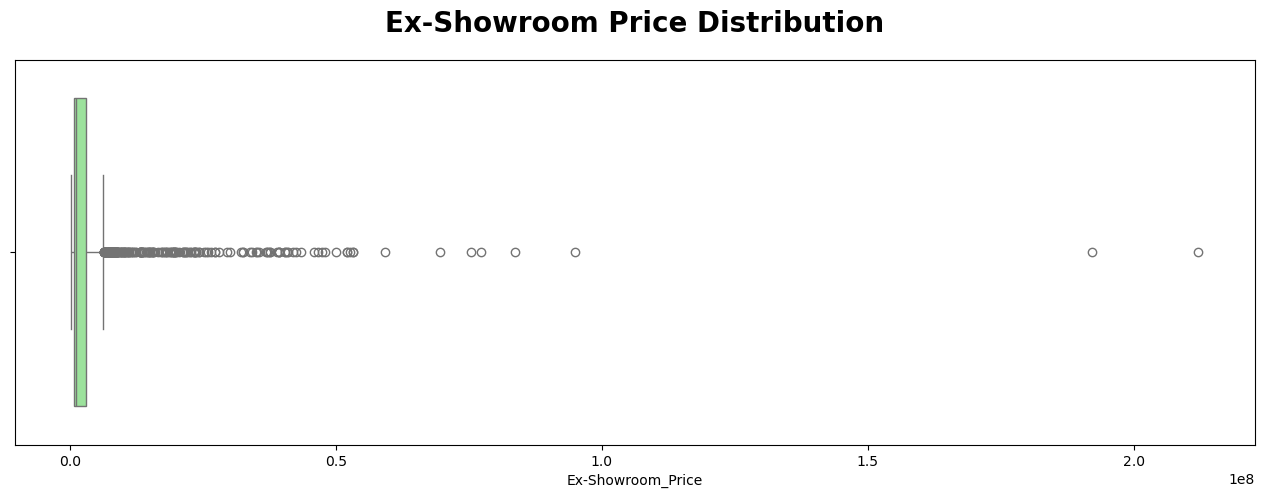

In [214]:
#Visualizing Ex-Showroom Price Distribution
plt.figure(figsize=(16,5))
sns.boxplot(x=df["Ex-Showroom_Price"], color="lightgreen")
plt.title("Ex-Showroom Price Distribution", fontweight="black", size=20, pad=20)
plt.show()

In [215]:
#Dropping Outliers.
df[df["Ex-Showroom_Price"]>150000000][["Car Manufacturer","Car Model","Ex-Showroom_Price"]]

,Car Manufacturer,Car Model,Ex-Showroom_Price
355,Bugatti,Chiron,192142937
356,Bugatti,Chiron,212155397


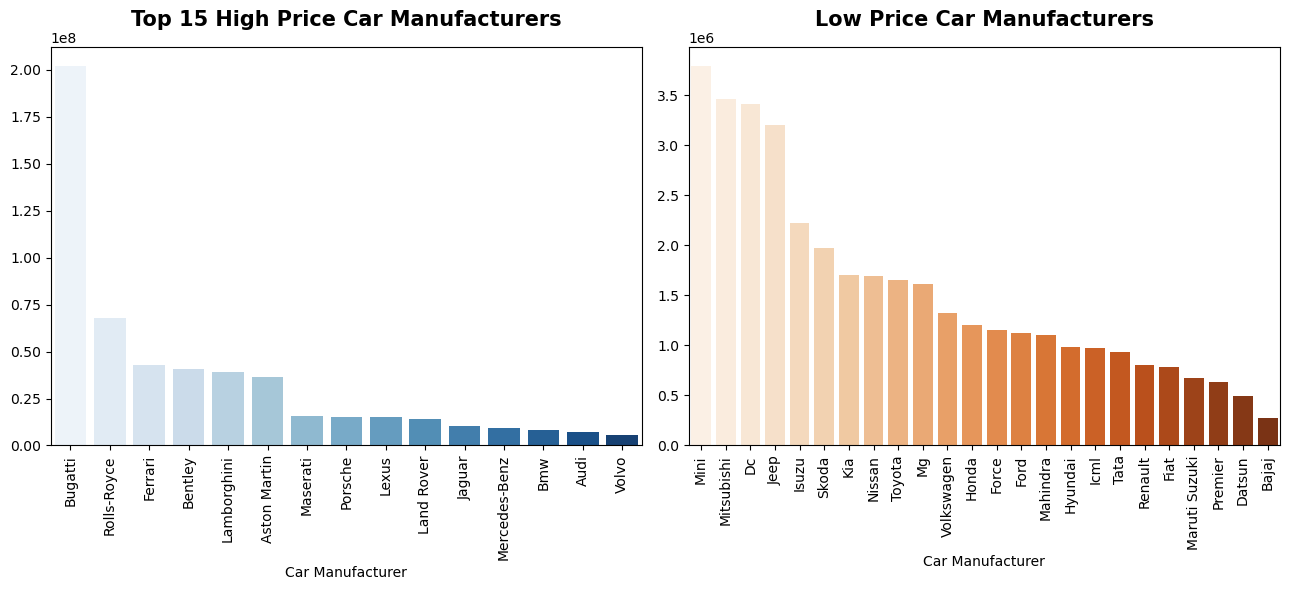

In [216]:
#Visualizing Avg. Price by Car Manufacturer
average_price1 = df.groupby(["Car Manufacturer"])["Ex-Showroom_Price"].mean().sort_values(ascending=False)[:15]
average_price2 = df.groupby(["Car Manufacturer"])["Ex-Showroom_Price"].mean().sort_values(ascending=False)[15:]

plt.figure(figsize=(13,6))

plt.subplot(1,2,1)
sns.barplot(
    x=average_price1.index,
    y=average_price1.values,
    palette="Blues"
)
plt.title("Top 15 High Price Car Manufacturers", fontweight="black", size=15, pad=15)
plt.xticks(rotation=90)

plt.subplot(1,2,2)
sns.barplot(
    x=average_price2.index,
    y=average_price2.values,
    palette="Oranges"
)
plt.title("Low Price Car Manufacturers", fontweight="black", size=15, pad=15)
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

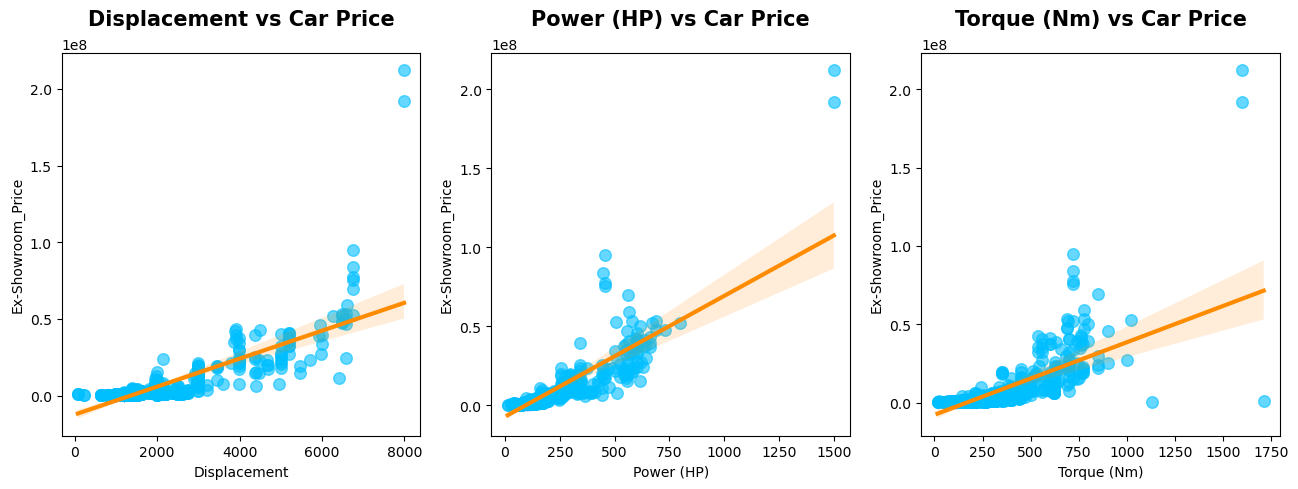

In [217]:
#Visualizing Displacement, Power & Torque Features
cols = ["Displacement", "Power (HP)", "Torque (Nm)"]

plt.figure(figsize=(13,5))

for index, column in enumerate(cols):
    plt.subplot(1,3,index+1)

    sns.regplot(
        x=column,
        y="Ex-Showroom_Price",
        data=df,
        color="blue",
        scatter_kws={"s":70, "alpha":0.6, "color":"deepskyblue"},
        line_kws={"color":"darkorange", "lw":3}
    )

    plt.title(f"{column} vs Car Price",
              fontweight="black", size=15, pad=20)

plt.tight_layout()
plt.show()

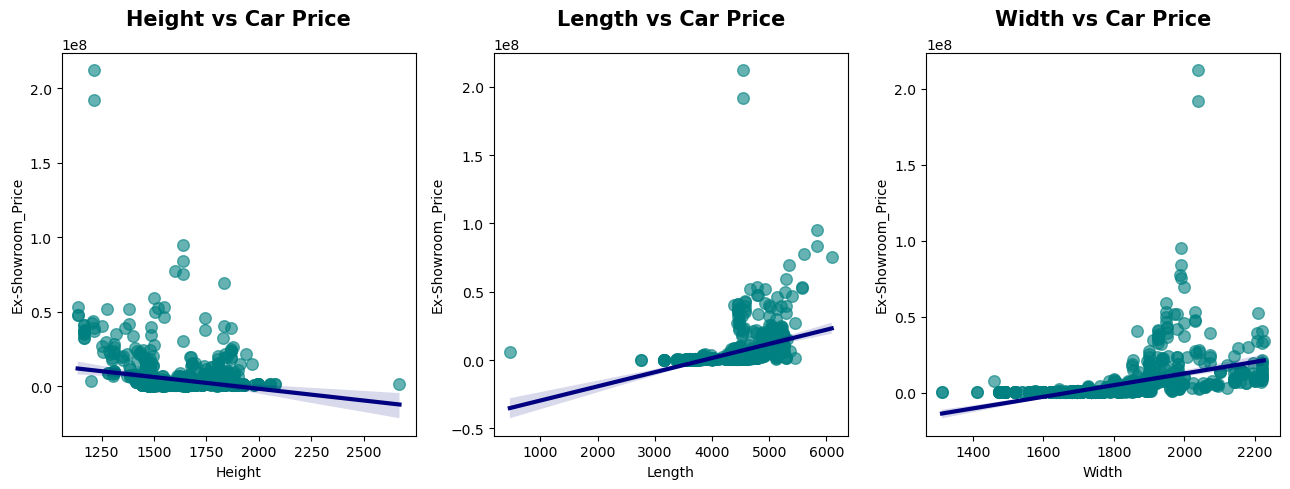

In [218]:
cols = ["Height", "Length", "Width"]

plt.figure(figsize=(13,5))

for index, column in enumerate(cols):
    plt.subplot(1,3,index+1)

    sns.regplot(
        x=column,
        y="Ex-Showroom_Price",
        data=df,
        scatter_kws={
            "color": "teal",
            "s": 70,
            "alpha": 0.6
        },
        line_kws={
            "color": "navy",
            "lw": 3
        }
    )

    plt.title(f"{column} vs Car Price",
              fontweight="black",
              size=15,
              pad=20)

plt.tight_layout()
plt.show()

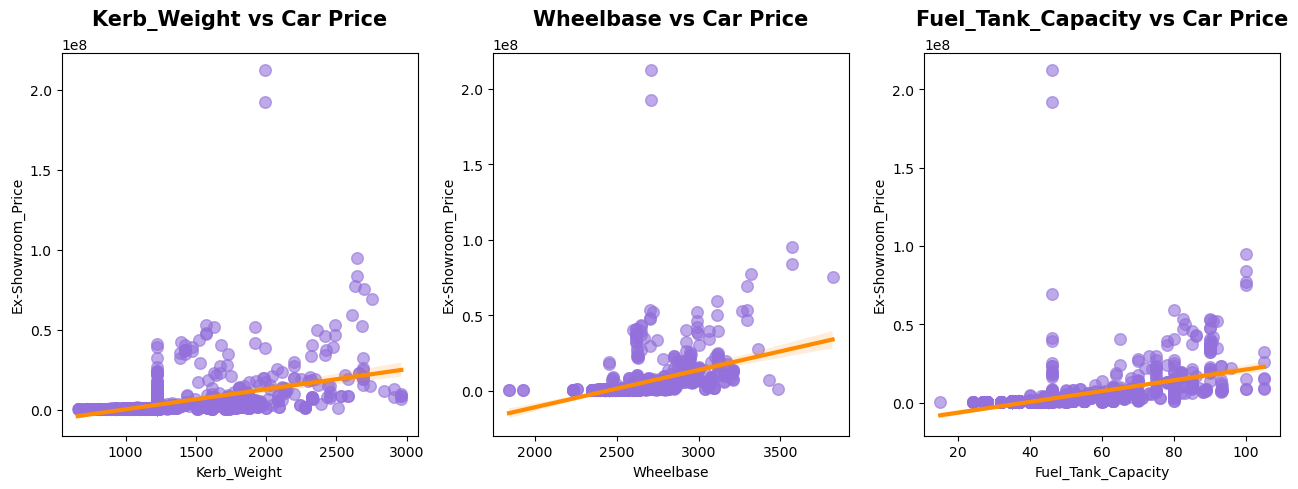

In [219]:
#Visualizing Weight, Wheelbase & Fuel_Tank_Capacity Features
cols = ["Kerb_Weight", "Wheelbase", "Fuel_Tank_Capacity"]

plt.figure(figsize=(13,5))

for index, column in enumerate(cols):
    plt.subplot(1,3,index+1)

    sns.regplot(
        x=column,
        y="Ex-Showroom_Price",
        data=df,
        scatter_kws={
            "color": "mediumpurple",
            "s": 70,
            "alpha": 0.6
        },
        line_kws={
            "color": "darkorange",
            "lw": 3
        }
    )

    plt.title(
        f"{column} vs Car Price",
        pad=20,
        fontweight="black",
        size=15
    )

plt.tight_layout()
plt.show()

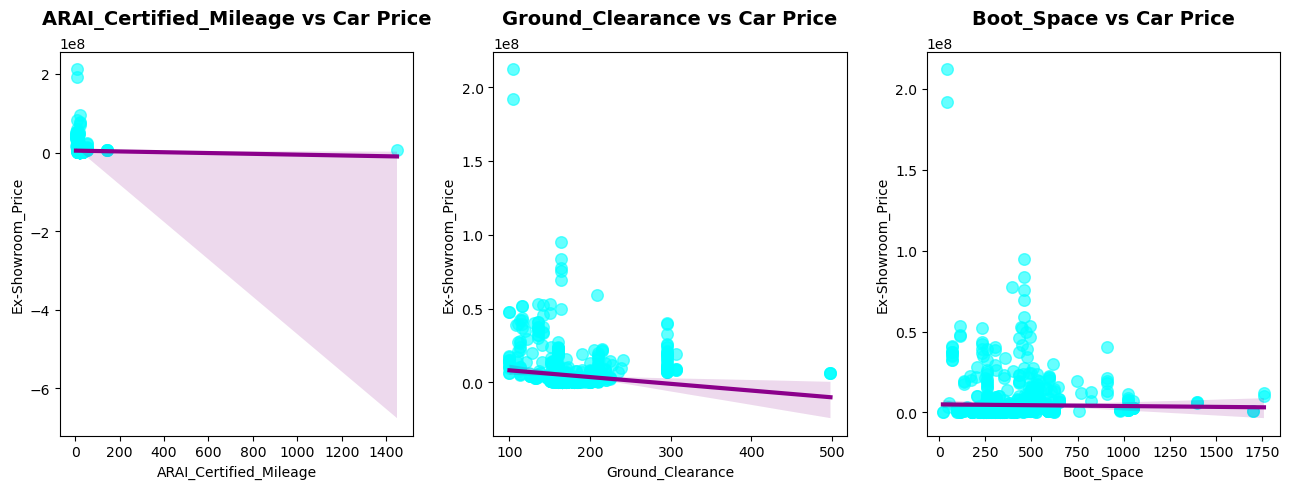

In [220]:
#Visualizing Mileage, Ground_Clearnace & Boot_Space Features
cols = ["ARAI_Certified_Mileage", "Ground_Clearance", "Boot_Space"]

plt.figure(figsize=(13,5))

for index, column in enumerate(cols):
    plt.subplot(1,3,index+1)

    sns.regplot(
        x=column,
        y="Ex-Showroom_Price",
        data=df,
        scatter_kws={
            "color": "cyan",
            "s": 70,
            "alpha": 0.6
        },
        line_kws={
            "color": "darkmagenta",
            "lw": 3
        }
    )

    plt.title(
        f"{column} vs Car Price",
        pad=20,
        fontweight="black",
        size=14
    )

plt.tight_layout()
plt.show()

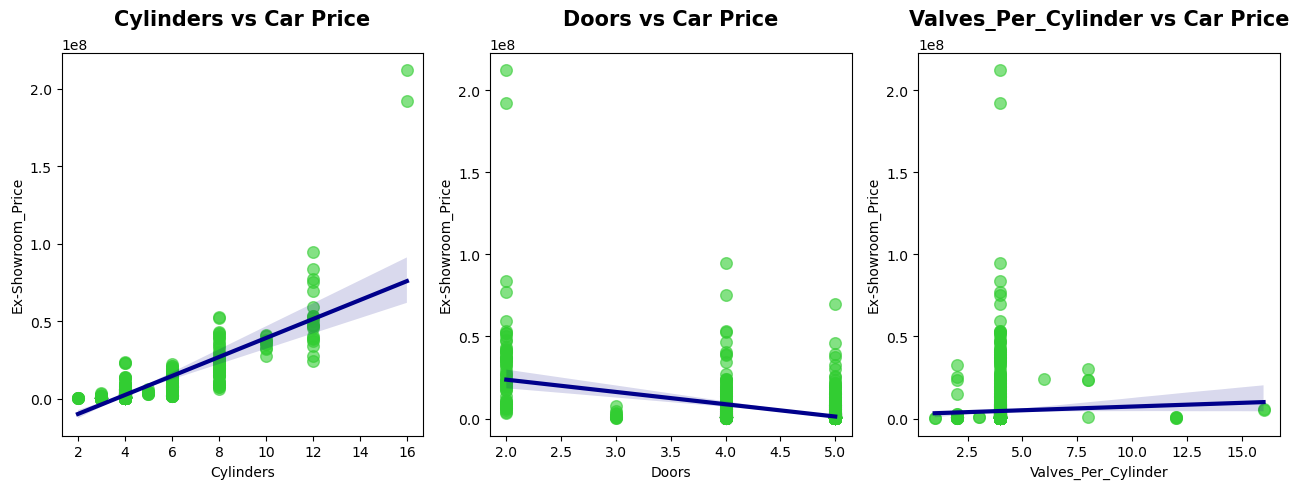

In [221]:
#Visualizing Cyclinders, Doors, Valves_Per_Cyclinder Features
cols = ['Cylinders', 'Doors', 'Valves_Per_Cylinder']

plt.figure(figsize=(13,5))

for index, column in enumerate(cols):
    plt.subplot(1,3,index+1)

    sns.regplot(
        x=column,
        y="Ex-Showroom_Price",
        data=df,
        scatter_kws={
            "color": "limegreen",
            "s": 70,
            "alpha": 0.6
        },
        line_kws={
            "color": "darkblue",
            "lw": 3
        }
    )

    plt.title(
        f"{column} vs Car Price",
        pad=20,
        fontweight="black",
        size=15
    )

plt.tight_layout()
plt.show()

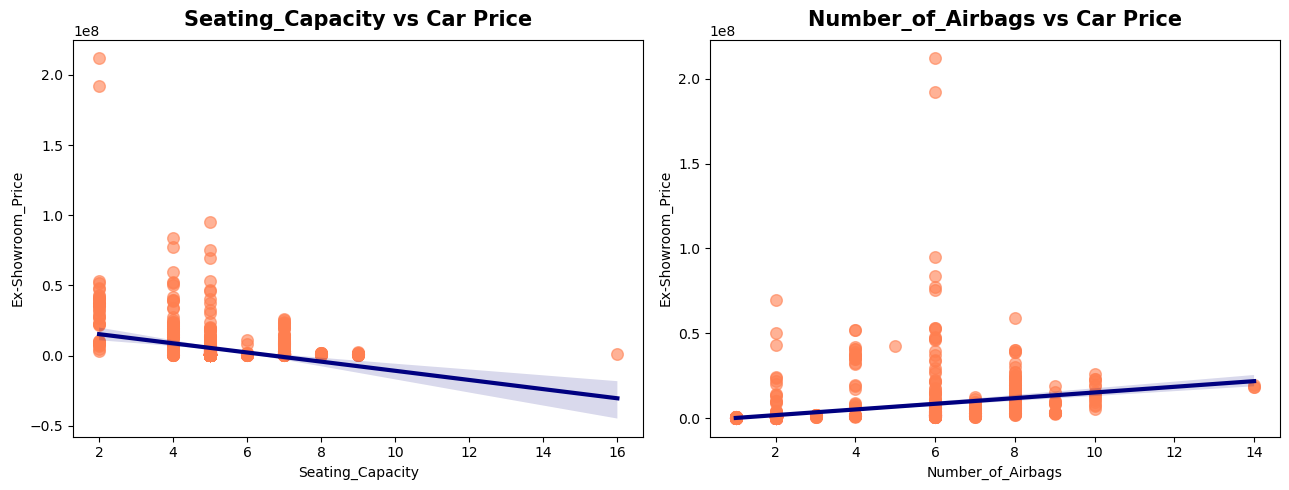

In [222]:
#Visualizing Seating_Capacity & Number_of_Airbags Features
cols = ['Seating_Capacity', 'Number_of_Airbags']

plt.figure(figsize=(13,5))

for index, column in enumerate(cols):
    plt.subplot(1,2,index+1)

    sns.regplot(
        x=column,
        y="Ex-Showroom_Price",
        data=df,
        scatter_kws={
            "color": "coral",
            "s": 70,
            "alpha": 0.6
        },
        line_kws={
            "color": "navy",
            "lw": 3
        }
    )

    plt.title(
        f"{column} vs Car Price",
        pad=10,
        fontweight="black",
        size=15
    )

plt.tight_layout()
plt.show()

---

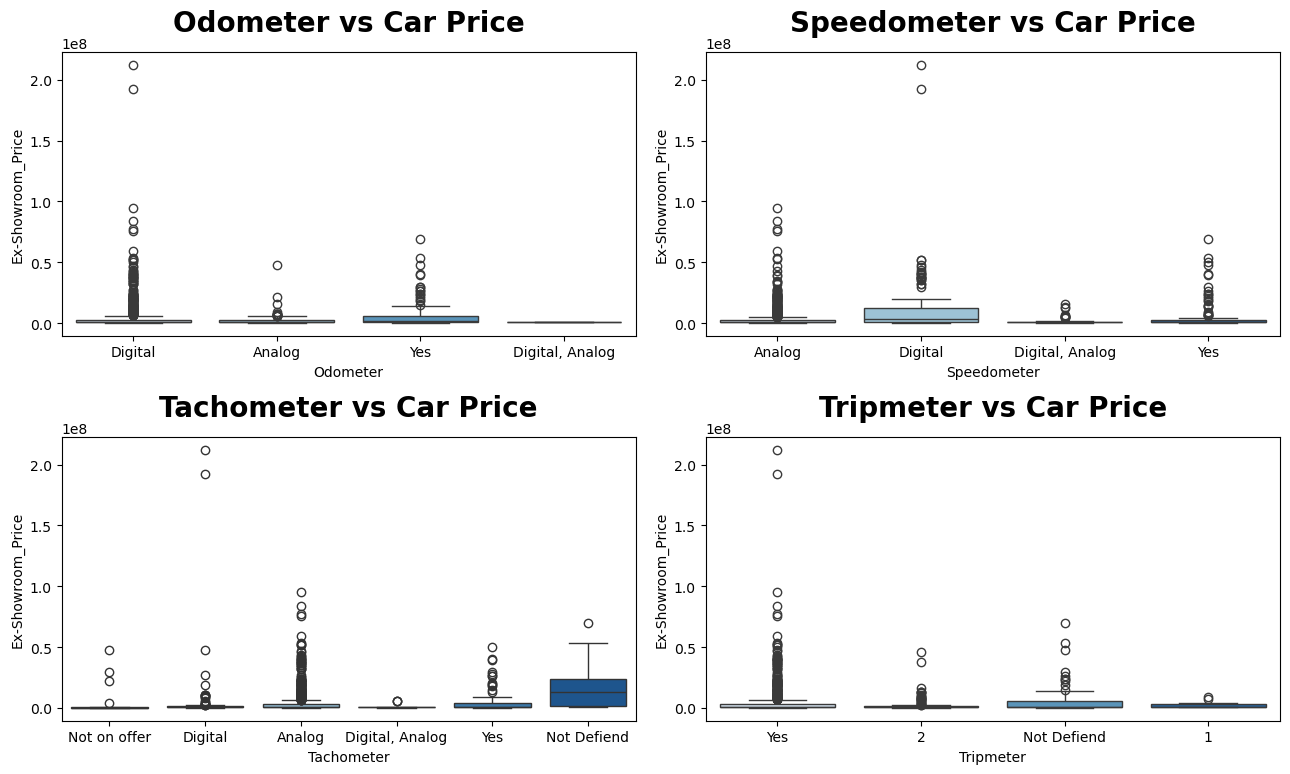

In [223]:
#Visualizing Odometer, Speedometer, Tachometer & Tripmeter
cols = ["Odometer", "Speedometer", "Tachometer", "Tripmeter"]

plt.figure(figsize=(13,8))

for index, column in enumerate(cols):
    plt.subplot(2,2,index+1)

    sns.boxplot(
        x=df[column],
        y=df["Ex-Showroom_Price"],
        palette="Blues"
    )

    plt.title(f"{column} vs Car Price",
              fontweight="black",
              size=20,
              pad=15)

plt.tight_layout()
plt.show()

---

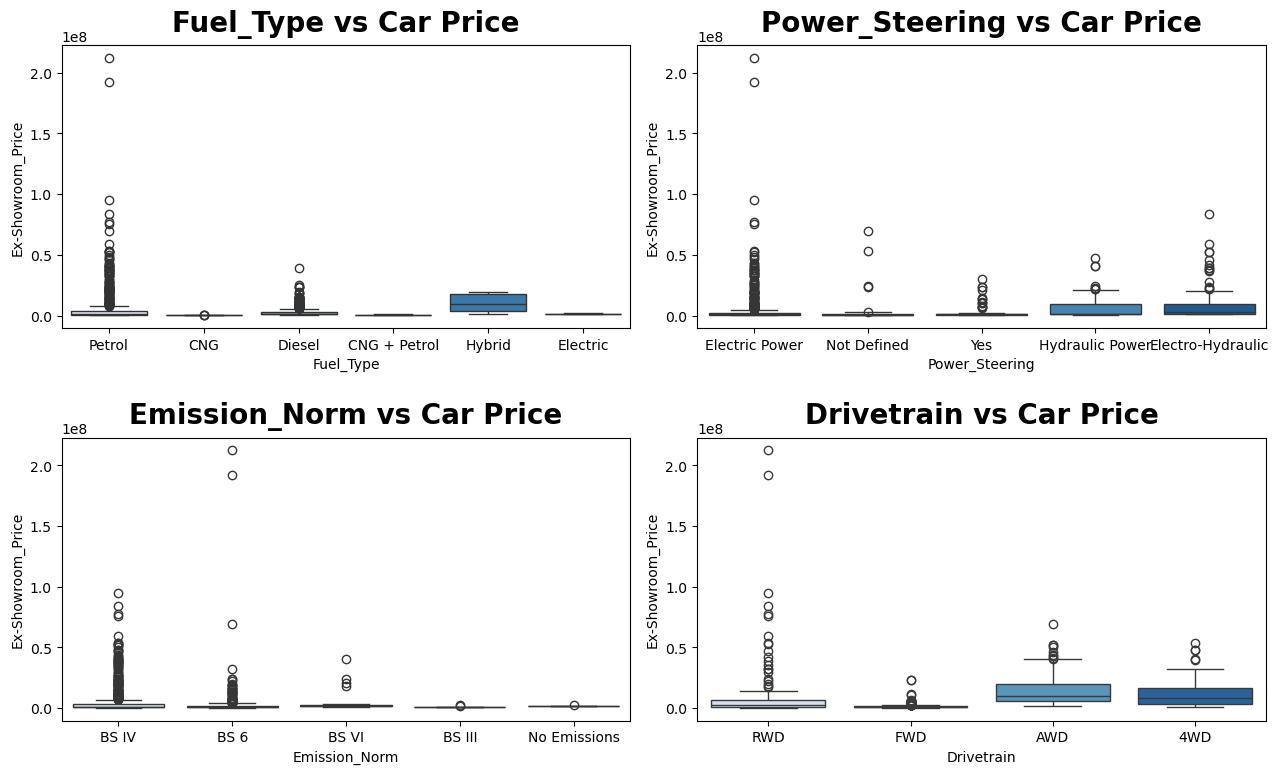

In [224]:
#Visualizing Fuel_Type, Power_Steering, Emission_Norm & Drivetrain
cols = ["Fuel_Type","Power_Steering","Emission_Norm","Drivetrain"]

plt.figure(figsize=(13,8))

for index, column in enumerate(cols):
    plt.subplot(2,2,index+1)

    sns.boxplot(
        x=df[column],
        y=df["Ex-Showroom_Price"],
        palette="Blues"
    )

    plt.title(f"{column} vs Car Price",
              fontweight="black",
              size=20,
              pad=10)
    plt.xticks(size=10)

plt.tight_layout()
plt.show()

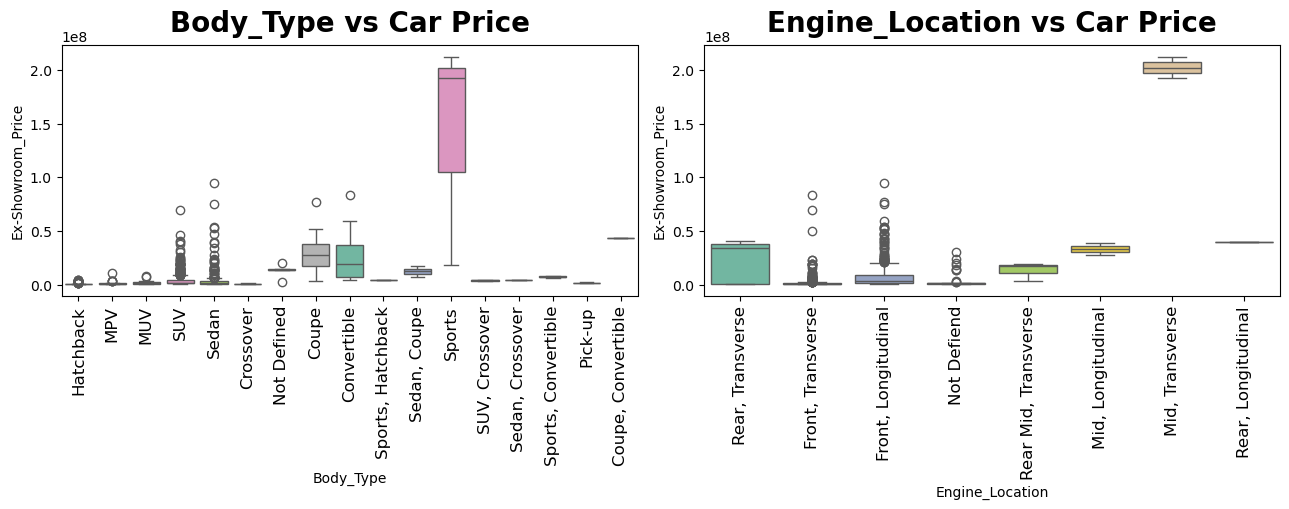

In [225]:
#Visualizing Body_Type & Engine_Location
cols = ["Body_Type", "Engine_Location"]

plt.figure(figsize=(13,8))

for index, column in enumerate(cols):
    plt.subplot(2,2,index+1)

    sns.boxplot(
        x=df[column],
        y=df["Ex-Showroom_Price"],
        palette="Set2"
    )

    plt.title(f"{column} vs Car Price",
              fontweight="black",
              size=20,
              pad=10)

    plt.xticks(rotation=90, fontsize=12)

plt.tight_layout()
plt.show()


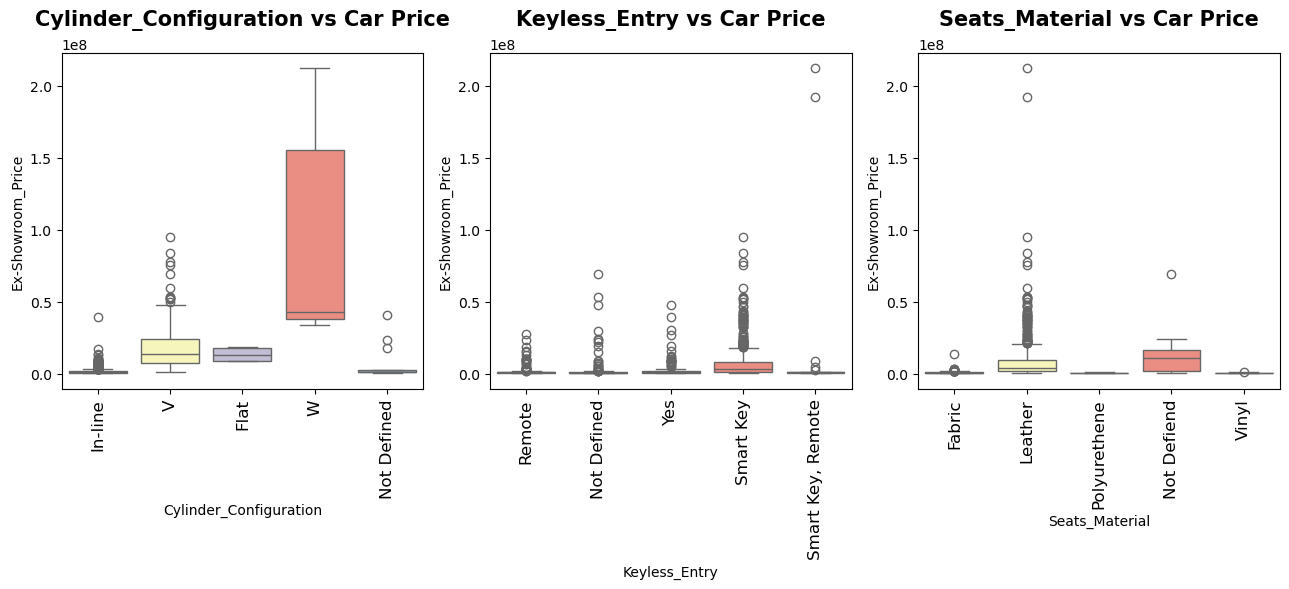

In [226]:
#Visualizing Cycliner_Configuration, Keyless_Entry & Seats_Material
cols = ["Cylinder_Configuration", "Keyless_Entry", "Seats_Material"]

plt.figure(figsize=(13,6))

for index, column in enumerate(cols):
    plt.subplot(1,3,index+1)

    sns.boxplot(
        x=df[column],
        y=df["Ex-Showroom_Price"],
        palette="Set3"
    )

    plt.title(
        f"{column} vs Car Price",
        fontweight="black",
        size=15,
        pad=20
    )

    plt.xticks(rotation=90, fontsize=12)

plt.tight_layout()
plt.show()

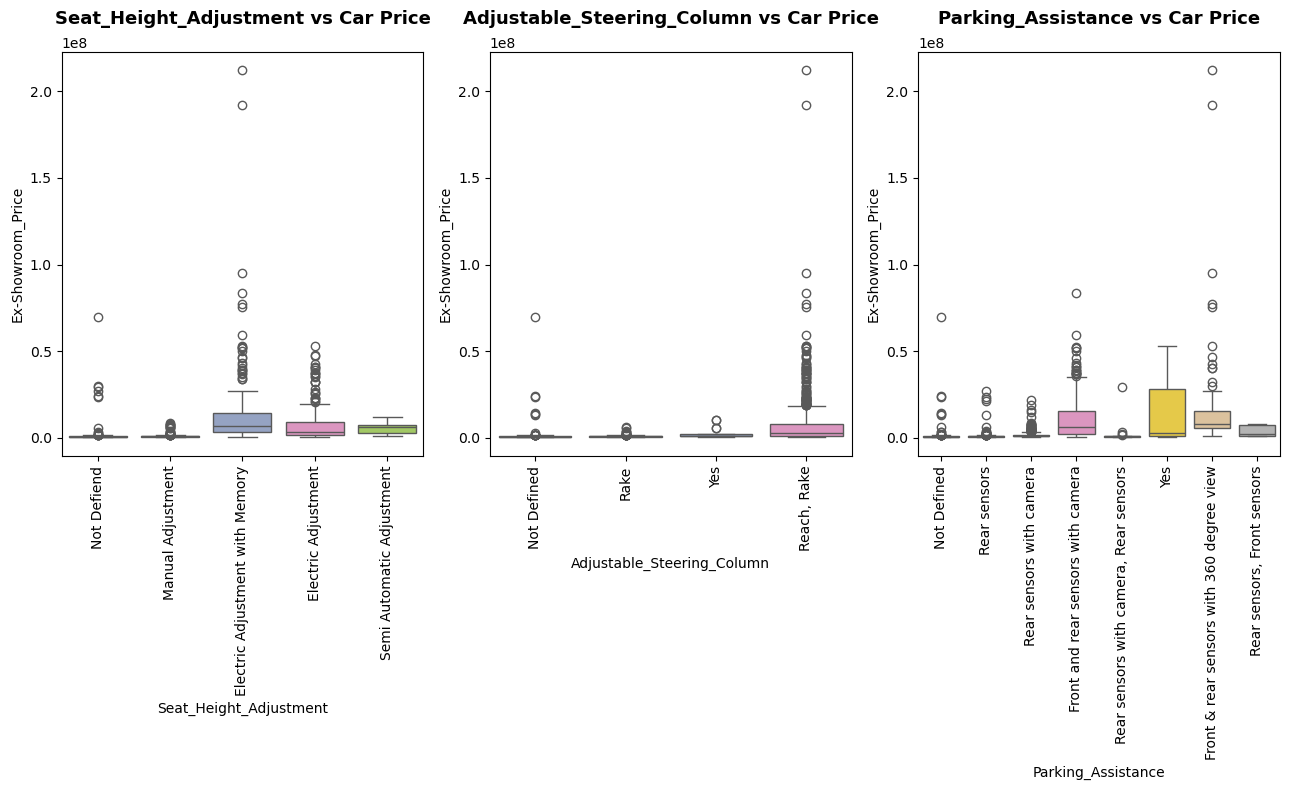

In [227]:
#Visualizing Seat_Height_Adjustment, Adjustable_Steering & Parking_Assistance
cols = ["Seat_Height_Adjustment", "Adjustable_Steering_Column", "Parking_Assistance"]

plt.figure(figsize=(13,8))

for index, column in enumerate(cols):
    plt.subplot(1,3,index+1)

    sns.boxplot(
        x=df[column],
        y=df["Ex-Showroom_Price"],
        palette="Set2"
    )

    plt.title(
        f"{column} vs Car Price",
        fontweight="black",
        size=13,
        pad=20
    )

    plt.xticks(rotation=90, fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
##FEATURE IMPORTANCE

In [ ]:
#Performing ANOVA Test on Binary Categorical Features.

In [228]:
cols = ['Central_Locking','Child_Safety_Locks','Low_Fuel_Warning','Third_Row_AC_Vents','Second_Row_AC_Vents',
        'Auto-Dimming_Rear-View_Mirror','Engine_Immobilizer','ABS_(Anti-lock_Braking_System)',
        'EBD_(Electronic_Brake-force_Distribution)','Cooled_Glove_Box','EBA_(Electronic_Brake_Assist)',
        'ESP_(Electronic_Stability_Program)','Gear_Shift_Reminder','Key_Off_Reminder','USB_Compatibility',
        'Bluetooth','Navigation_System','Turbocharger',"Automatic_Headlamps","Cruise_Control"]
print(len(cols))

20


In [231]:
missing = [col for col in cols if col not in df.columns]
print("Missing columns:", missing)

Missing columns: ['ESP_(Electronic_Stability_Program)', 'Automatic_Headlamps']


In [232]:
cols = [col for col in cols if col in df.columns]

x = df[cols]
y = df["Ex-Showroom_Price"]

In [233]:
x = df[cols]
y = df["Ex-Showroom_Price"]

In [234]:
enc = LabelEncoder()
x[cols] = x[cols].apply(enc.fit_transform)

In [236]:
from sklearn.feature_selection import SelectKBest, f_regression
selector = SelectKBest(score_func=f_regression, k=5) 
selector.fit(x, y)

,score_func,<function f_r...002610137A840>
,k,5


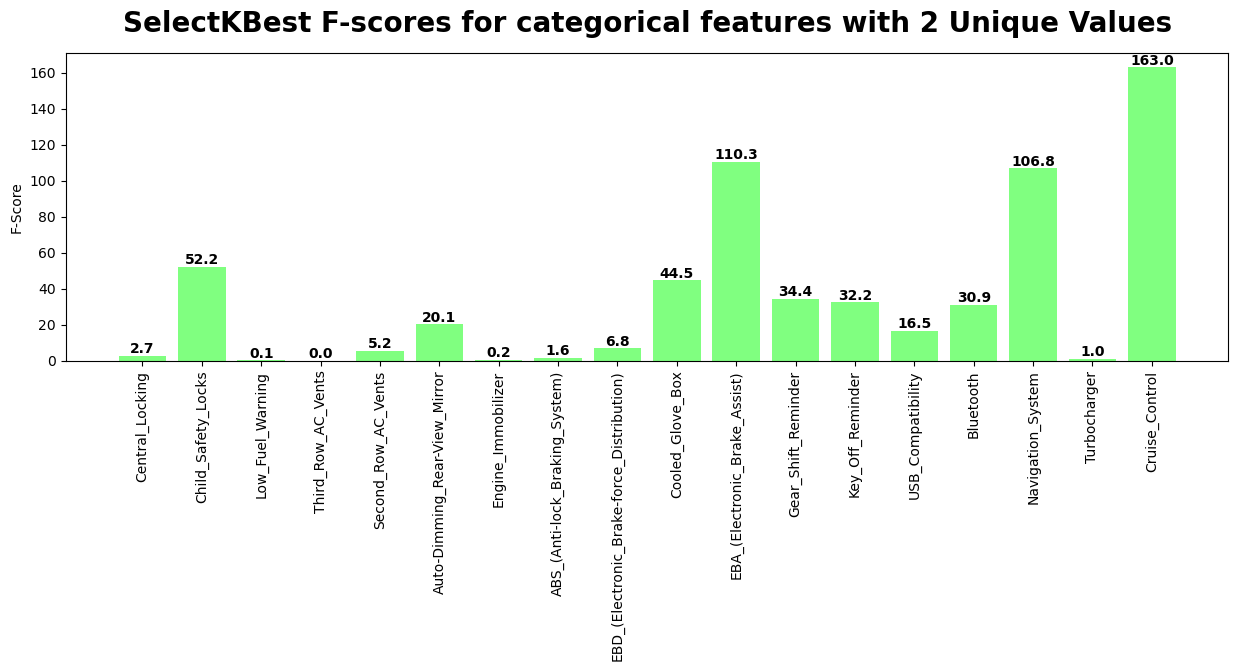

In [238]:
#Visualizing the F-score of the these features
scores = selector.scores_
feature_names = x.columns

plt.figure(figsize=(15, 4))
plt.bar(feature_names,scores,color=(0.5, 1.0, 0.5))
for index,value in enumerate(scores):
    plt.text(index,value,round(value,1),ha="center",fontweight="bold",va="bottom")
plt.ylabel('F-Score')
plt.xticks(rotation=90,size=10)
plt.title('SelectKBest F-scores for categorical features with 2 Unique Values',pad=15,fontweight="black",size=20)
plt.show()

In [239]:
#Selecting Useful Features

In [240]:
useful_features_1 = x.columns[selector.get_support(indices=True)]
useful_features_1

Index(['Child_Safety_Locks', 'Cooled_Glove_Box',
       'EBA_(Electronic_Brake_Assist)', 'Navigation_System', 'Cruise_Control'],
      dtype='object')

In [241]:
#Performing ANOVA Test on Categorical Features with Multiple Categories

In [242]:
cols = ["Odometer","Speedometer","Tachometer","Tripmeter","Fuel_Type","Power_Steering","Emission_Norm","Drivetrain",
        "Body_Type","Engine_Location","Cylinder_Configuration","Keyless_Entry","Seats_Material",
        "Seat_Height_Adjustment","Adjustable_Steering_Column","Parking_Assistance"]
print(len(cols))

16


In [243]:
x = df[cols]
y = df["Ex-Showroom_Price"]

In [244]:
enc = LabelEncoder()
x[cols] = x[cols].apply(enc.fit_transform)

In [245]:
selector = SelectKBest(score_func = f_regression, k=5)
selector.fit(x,y)

,score_func,<function f_r...002610137A840>
,k,5


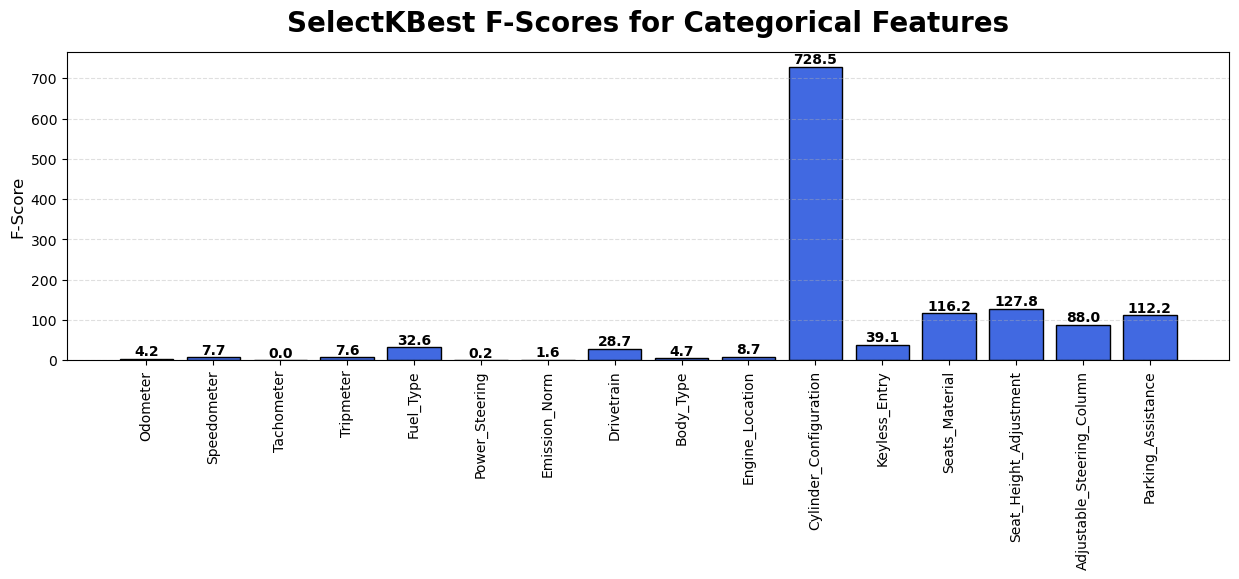

In [246]:
#Visualizing the F-score of these Features
scores = selector.scores_
feature_names = x.columns

plt.figure(figsize=(15,4))

plt.bar(
    feature_names,
    scores,
    color="royalblue",
    edgecolor="black"
)

for index, value in enumerate(scores):
    plt.text(
        index,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.ylabel("F-Score", fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.title(
    "SelectKBest F-Scores for Categorical Features",
    fontweight="black",
    size=20,
    pad=15
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [247]:
#Selecting Useful Features
useful_features_2 = x.columns[selector.get_support(indices=True)]
useful_features_2

Index(['Cylinder_Configuration', 'Seats_Material', 'Seat_Height_Adjustment',
       'Adjustable_Steering_Column', 'Parking_Assistance'],
      dtype='object')

In [248]:
#3. Performing ANOVA Test on Discrete Numerical Features

In [251]:
cols = ['Cylinders','Doors','Valves_Per_Cylinder','Seating_Capacity','Number_of_Airbags']

In [252]:
x = df[cols]
y = df["Ex-Showroom_Price"]

In [253]:
selector = SelectKBest(score_func=f_regression,k=1)
selector.fit(x,y)

,score_func,<function f_r...002610137A840>
,k,1


In [254]:
#Visualizing the F-score of these features

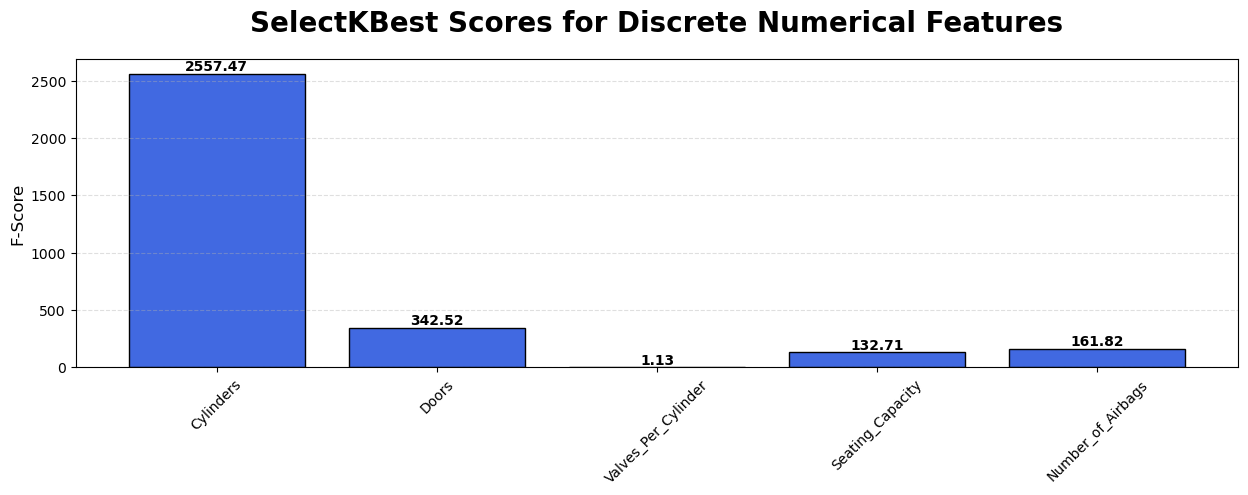

In [255]:
scores = selector.scores_
feature_names = x.columns

plt.figure(figsize=(15,4))

plt.bar(
    feature_names,
    scores,
    color="royalblue",
    edgecolor="black"
)

for index, value in enumerate(scores):
    plt.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.ylabel("F-Score", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.title(
    "SelectKBest Scores for Discrete Numerical Features",
    pad=20,
    fontweight="black",
    size=20
)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

In [256]:
#Selecting Useful Features
useful_features_3 = x.columns[selector.get_support(indices=True)]
useful_features_3

Index(['Cylinders'], dtype='object')

In [ ]:
#4. Performing Correlation Analysis on Continous Numerical Features

In [257]:
cols = ["Displacement","Power (HP)","Torque (Nm)","Height","Length","Width","Kerb_Weight","Wheelbase","Fuel_Tank_Capacity",
        "ARAI_Certified_Mileage","Ground_Clearance","Boot_Space",'Ex-Showroom_Price']

In [258]:
new_df = df[cols]
corr = new_df.corr()["Ex-Showroom_Price"].to_frame().rename(columns={"Ex-Showroom_Price":"Correlation with Price"})

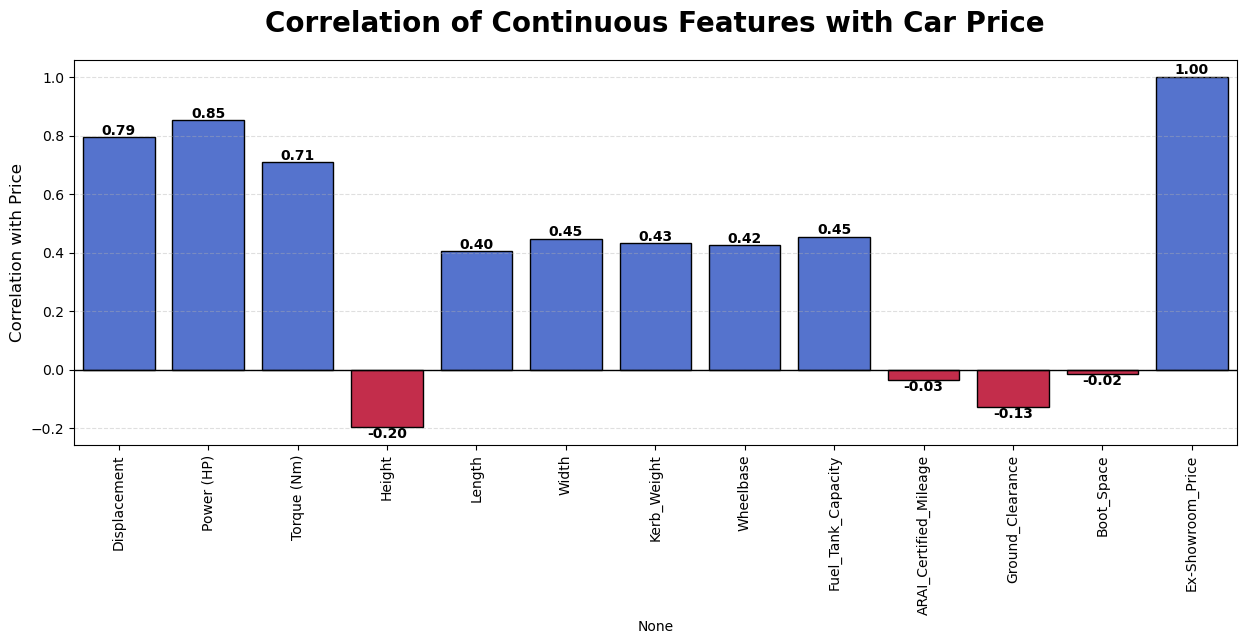

In [260]:
positive_color = "royalblue"
negative_color = "crimson"

colors = [
    positive_color if c >= 0 else negative_color
    for c in corr["Correlation with Price"]
]

plt.figure(figsize=(15,5))

ax = sns.barplot(
    x=corr.index,
    y=corr["Correlation with Price"],
    palette=colors,
    edgecolor="black"
)

for i, val in enumerate(corr["Correlation with Price"]):
    ax.text(
        i,
        val,
        f"{val:.2f}",
        ha="center",
        va="bottom" if val >= 0 else "top",
        fontweight="bold"
    )

plt.axhline(0, color="black", linewidth=1)

plt.title(
    "Correlation of Continuous Features with Car Price",
    fontweight="black",
    fontsize=20,
    pad=20
)

plt.ylabel("Correlation with Price", fontsize=12)
plt.xticks(rotation=90, fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

In [261]:
#Selecting Useful Features
useful_features_4 = ["Displacement","Power (HP)","Torque (Nm)","Length","Width","Kerb_Weight","Wheelbase",
                    "Fuel_Tank_Capacity","ARAI_Certified_Mileage",'Ex-Showroom_Price']

In [262]:
#5. Creating Data-Frame with Useful Features
useful_cols = []
useful_cols.extend(useful_features_1.tolist())
useful_cols.extend(useful_features_2.tolist())
useful_cols.extend(useful_features_3.tolist())
useful_cols.extend(useful_features_4)

In [263]:
df = df[useful_cols]
df.sample(5)

,Child_Safety_Locks,Cooled_Glove_Box,EBA_(Electronic_Brake_Assist),Navigation_System,Cruise_Control,Cylinder_Configuration,Seats_Material,Seat_Height_Adjustment,Adjustable_Steering_Column,Parking_Assistance,...,Displacement,Power (HP),Torque (Nm),Length,Width,Kerb_Weight,Wheelbase,Fuel_Tank_Capacity,ARAI_Certified_Mileage,Ex-Showroom_Price
726,Yes,Not Defined,Not Defined,Yes,Not Defined,V,Leather,Electric Adjustment with Memory,"Reach, Rake",Rear sensors,...,1956.0,170.63,350.0,4395.0,1818.0,1537.0,2636.0,60.0,17.10,1699000
1057,Yes,Yes,Yes,Yes,Yes,V,Leather,Electric Adjustment with Memory,"Reach, Rake",Front and rear sensors with camera,...,5935.0,552.34,630.0,5019.0,1929.0,1990.0,2989.0,90.5,12.90,38845823
511,Yes,Yes,Not Defined,Yes,Not Defined,In-line,Fabric,Manual Adjustment,"Reach, Rake",Rear sensors with camera,...,1198.0,108.50,170.0,3994.0,1811.0,1225.0,2498.0,44.0,17.60,1010000
1066,Yes,Yes,Not Defined,Not Defined,Not Defined,In-line,Fabric,Manual Adjustment,Rake,Rear sensors,...,1197.0,81.86,114.0,3805.0,1680.0,935.0,2450.0,37.0,20.70,703350
109,Yes,Not Defined,Not Defined,Not Defined,Not Defined,In-line,Fabric,Not Defiend,Rake,Not Defined,...,1193.0,88.77,140.0,3825.0,1695.0,1095.0,2470.0,44.0,17.57,529035


In [264]:
df.shape

(1276, 21)

In [265]:
df.head()

,Child_Safety_Locks,Cooled_Glove_Box,EBA_(Electronic_Brake_Assist),Navigation_System,Cruise_Control,Cylinder_Configuration,Seats_Material,Seat_Height_Adjustment,Adjustable_Steering_Column,Parking_Assistance,...,Displacement,Power (HP),Torque (Nm),Length,Width,Kerb_Weight,Wheelbase,Fuel_Tank_Capacity,ARAI_Certified_Mileage,Ex-Showroom_Price
0,Yes,Not Defined,Not Defined,Not Defined,Not Defined,In-line,Fabric,Not Defiend,Not Defined,Not Defined,...,624.0,37.48,51.0,3164.0,1750.0,660.0,2230.0,24.0,23.600000,292667
1,Yes,Not Defined,Not Defined,Not Defined,Not Defined,In-line,Fabric,Not Defiend,Not Defined,Not Defined,...,624.0,37.48,51.0,3164.0,1750.0,725.0,2230.0,24.0,23.600000,236447
2,Yes,Not Defined,Not Defined,Not Defined,Not Defined,In-line,Fabric,Not Defiend,Not Defined,Not Defined,...,624.0,37.48,51.0,3164.0,1750.0,710.0,2230.0,15.0,20.533095,296661
3,Yes,Not Defined,Not Defined,Not Defined,Not Defined,In-line,Fabric,Not Defiend,Not Defined,Not Defined,...,624.0,37.48,51.0,3164.0,1750.0,725.0,2230.0,24.0,21.900000,334768
4,Yes,Not Defined,Not Defined,Not Defined,Not Defined,In-line,Fabric,Not Defiend,Not Defined,Not Defined,...,624.0,37.48,51.0,3164.0,1750.0,725.0,2230.0,24.0,23.600000,272223


In [266]:
## feature engineering

In [267]:
df["Power_to_Weight"] = df["Power (HP)"] / df["Kerb_Weight"]

In [268]:
df["Torque_per_Cylinder"] = df["Torque (Nm)"] / df["Cylinders"]

In [269]:
df["Driving_Range"] = (
    df["ARAI_Certified_Mileage"] *
    df["Fuel_Tank_Capacity"]
)

In [270]:
df["Wheelbase_Length_Ratio"] = (
    df["Wheelbase"] /
    df["Length"]
)

In [ ]:
##Data Preprocessing

In [271]:
#Computing Skewness of Continous Numerical Features

In [272]:
cols = ["Displacement","Power (HP)","Torque (Nm)","Length","Width","Kerb_Weight","Wheelbase",
        "Fuel_Tank_Capacity","ARAI_Certified_Mileage",'Ex-Showroom_Price']

In [273]:
df[cols].skew().to_frame().rename(columns={0:"Skewness"})

,Skewness
Displacement,2.563645
Power (HP),3.388333
Torque (Nm),2.066967
Length,-0.176872
Width,0.768230
Kerb_Weight,1.346789
Wheelbase,0.989314
Fuel_Tank_Capacity,1.011710
ARAI_Certified_Mileage,33.312371
Ex-Showroom_Price,8.785169


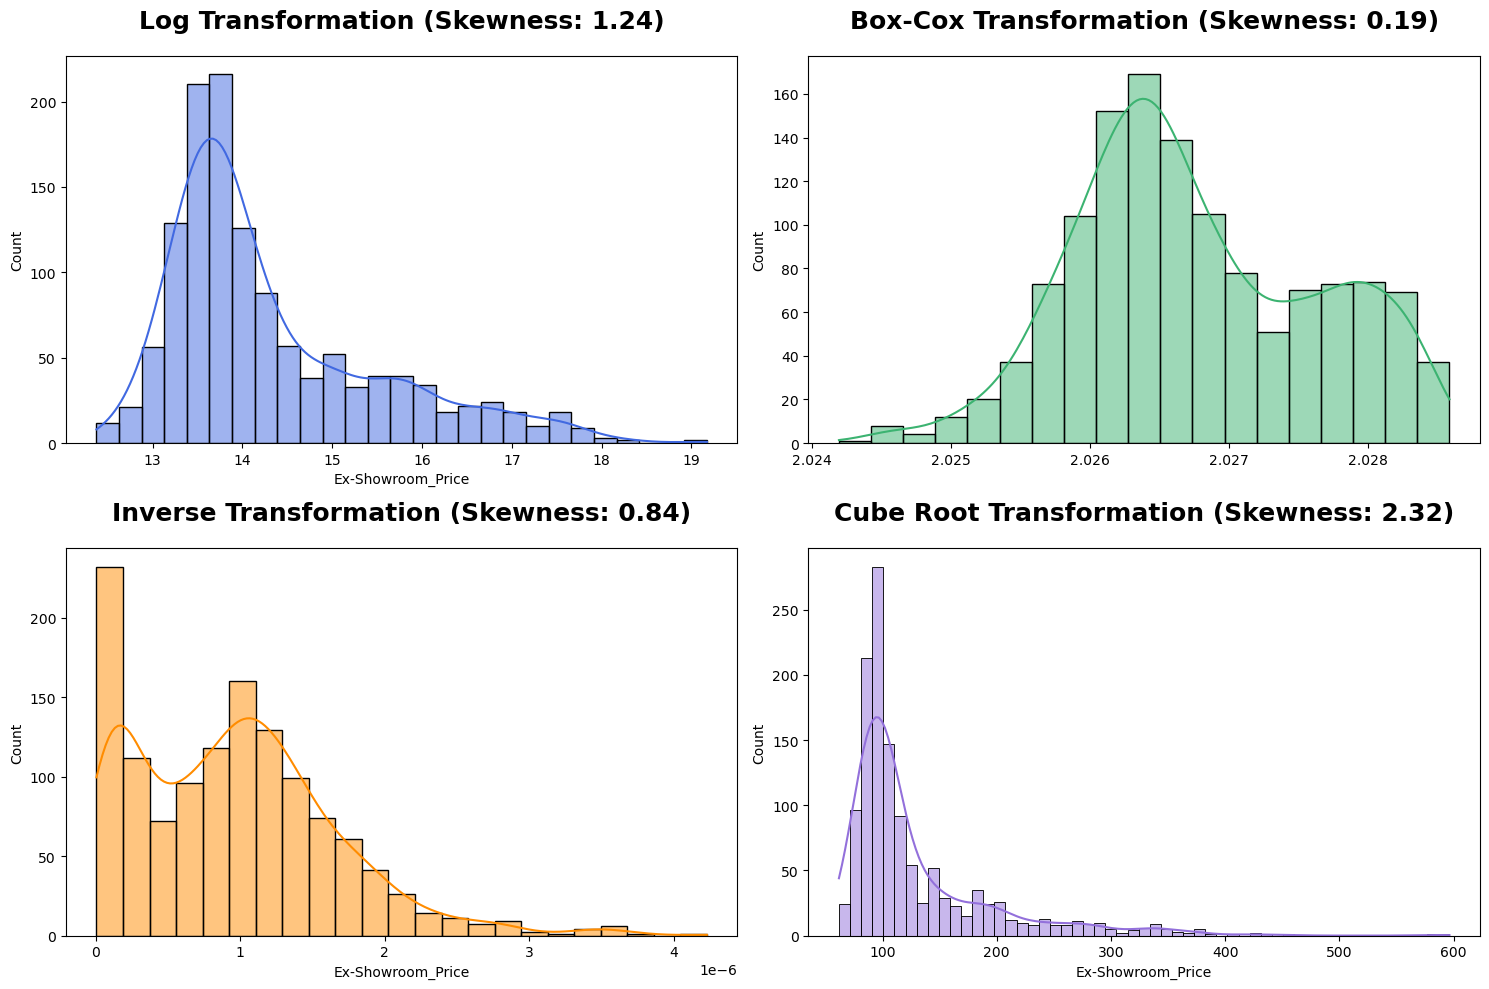

In [274]:
#Visualizing which Transformation will have best fit for target variable
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

# Log Transformation
transformed_log = np.log(df["Ex-Showroom_Price"])
skewness_log = stats.skew(transformed_log)
plt.subplot(2,2,1)
sns.histplot(transformed_log, kde=True, color="royalblue")
plt.title(f"Log Transformation (Skewness: {skewness_log:.2f})",
          fontweight="black", fontsize=18, pad=20)

# Box-Cox Transformation
transformed_boxcox, lambda_param = stats.boxcox(df["Ex-Showroom_Price"])
skewness_boxcox = stats.skew(transformed_boxcox)
plt.subplot(2,2,2)
sns.histplot(transformed_boxcox, kde=True, color="mediumseagreen")
plt.title(f"Box-Cox Transformation (Skewness: {skewness_boxcox:.2f})",
          fontweight="black", fontsize=18, pad=20)

# Inverse Transformation
transformed_inverse = 1 / df["Ex-Showroom_Price"]
skewness_inverse = stats.skew(transformed_inverse)
plt.subplot(2,2,3)
sns.histplot(transformed_inverse, kde=True, color="darkorange")
plt.title(f"Inverse Transformation (Skewness: {skewness_inverse:.2f})",
          fontweight="black", fontsize=18, pad=20)

# Cube Root Transformation
transformed_cbrt = np.cbrt(df["Ex-Showroom_Price"])
skewness_cbrt = stats.skew(transformed_cbrt)
plt.subplot(2,2,4)
sns.histplot(transformed_cbrt, kde=True, color="mediumpurple")
plt.title(f"Cube Root Transformation (Skewness: {skewness_cbrt:.2f})",
          fontweight="black", fontsize=18, pad=20)

plt.tight_layout()
plt.show()

In [275]:
#Applying Box-Cox Tansformation

In [276]:
for column in cols:
    df[column], lamda_param = stats.boxcox(df[column])

In [277]:
df[cols].skew().to_frame().rename(columns={0:"Skewness"})

,Skewness
Displacement,-0.011170
Power (HP),-0.112817
Torque (Nm),-0.000609
Length,0.125701
Width,0.000000
Kerb_Weight,-0.007237
Wheelbase,0.000000
Fuel_Tank_Capacity,0.000379
ARAI_Certified_Mileage,-0.236289
Ex-Showroom_Price,0.187201


In [278]:
#Encoding Categorical Features

In [279]:
cat_cols = df.select_dtypes(include=["object"]).columns

In [280]:
df = pd.get_dummies(df,columns=cat_cols)

In [281]:
df.sample(5)

,Cylinders,Displacement,Power (HP),Torque (Nm),Length,Width,Kerb_Weight,Wheelbase,Fuel_Tank_Capacity,ARAI_Certified_Mileage,...,"Adjustable_Steering_Column_Reach, Rake",Adjustable_Steering_Column_Yes,Parking_Assistance_Front & rear sensors with 360 degree view,Parking_Assistance_Front and rear sensors with camera,Parking_Assistance_Not Defined,Parking_Assistance_Rear sensors,Parking_Assistance_Rear sensors with camera,"Parking_Assistance_Rear sensors with camera, Rear sensors","Parking_Assistance_Rear sensors, Front sensors",Parking_Assistance_Yes
779,4.0,7.261909,2.241204,5.904697,66500.775548,0.773320,1.778505,0.606622,1.995768,2.184406,...,False,False,True,False,False,False,False,False,False,False
605,4.0,7.070449,2.090434,4.863809,61795.678163,0.773308,1.771519,0.606622,1.959506,2.129980,...,True,False,False,False,False,True,False,False,False,False
898,4.0,6.802398,2.076540,4.636406,53412.493712,0.773308,1.769359,0.606622,1.904934,2.262747,...,False,False,False,False,False,False,True,False,False,False
1112,4.0,7.070449,2.090434,4.863809,62233.546663,0.773308,1.772388,0.606622,1.959506,2.083278,...,True,False,False,False,False,True,False,False,False,False
426,4.0,6.843139,2.035504,5.065912,51571.246279,0.773309,1.768241,0.606622,1.877108,2.375751,...,False,False,False,False,False,True,False,False,False,False


In [282]:
#Segregating Features & Labels for Model Training

In [283]:
X = df.drop(columns="Ex-Showroom_Price")
y = df["Ex-Showroom_Price"]

In [284]:
X.shape

(1276, 51)

In [285]:
##Scaling Features using Robust Scaler

In [286]:
from sklearn.preprocessing import RobustScaler

In [287]:
scaler = RobustScaler()

In [288]:
x_scaled = scaler.fit_transform(X)

In [289]:
##Splitting Data for Model Training & Tetsing

In [290]:
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y,test_size=0.2,random_state=0)

In [291]:
print("Dimension of x_train:=>",x_train.shape)
print("Dimension of x_test:=>",x_test.shape)
print("Dimension of y_train:=>",y_train.shape)
print("Dimension of y_test:=>",y_test.shape)

Dimension of x_train:=> (1020, 51)
Dimension of x_test:=> (256, 51)
Dimension of y_train:=> (1020,)
Dimension of y_test:=> (256,)


In [ ]:
##Model Creation & Evaluation

In [292]:
#Creating a Function for Model Training & Model Evaluation

In [293]:
r2score = []
adj_r2_score = []
mae_score = []
mse_score = []
rmse_score = []
mpe_score = []
mape_score = []

In [295]:
def model_evaluation(model):
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    n = len(y)
    k = x.shape[1]

    # Metric Calculation
    r2 = r2_score(y_test, y_test_pred)
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
    mae = mean_absolute_error(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    mpe = np.mean((y_test - y_test_pred) / y_test) * 100
    mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

    # Append Metrics
    r2score.append(r2)
    adj_r2_score.append(adj_r2)
    mae_score.append(mae)
    mse_score.append(mse)
    rmse_score.append(rmse)
    mpe_score.append(mpe)
    mape_score.append(mape)

    # Print Metrics
    print("-" * 120)
    print(f"R² Score               : {r2:.4f}")
    print(f"Adjusted R² Score      : {adj_r2:.4f}")
    print(f"Mean Absolute Error    : {mae:.4f}")
    print(f"Mean Squared Error     : {mse:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"Mean Percentage Error  : {mpe:.2f}%")
    print(f"MAPE                   : {mape:.2f}%")
    print("-" * 120)

    # Scatter Plot
    plt.figure(figsize=(15,5))

    plt.subplot(1,2,1)
    plt.scatter(y_train, y_train_pred, color="royalblue", alpha=0.7, label="Train")
    plt.scatter(y_test, y_test_pred, color="crimson", alpha=0.7, label="Test")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title("Scatter Plot", fontsize=18, fontweight="bold")
    plt.legend()

    # Residual Plot
    plt.subplot(1,2,2)
    plt.scatter(y_train_pred, y_train_pred - y_train,
                color="royalblue", alpha=0.7, label="Train")
    plt.scatter(y_test_pred, y_test_pred - y_test,
                color="crimson", alpha=0.7, label="Test")
    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot", fontsize=18, fontweight="bold")
    plt.legend()

    plt.tight_layout()
    plt.show()

------------------------------------------------------------------------------------------------------------------------
R² Score               : 0.9534
Adjusted R² Score      : 0.9532
Mean Absolute Error    : 0.0001
Mean Squared Error     : 0.0000
Root Mean Squared Error: 0.0002
Mean Percentage Error  : -0.00%
MAPE                   : 0.01%
------------------------------------------------------------------------------------------------------------------------


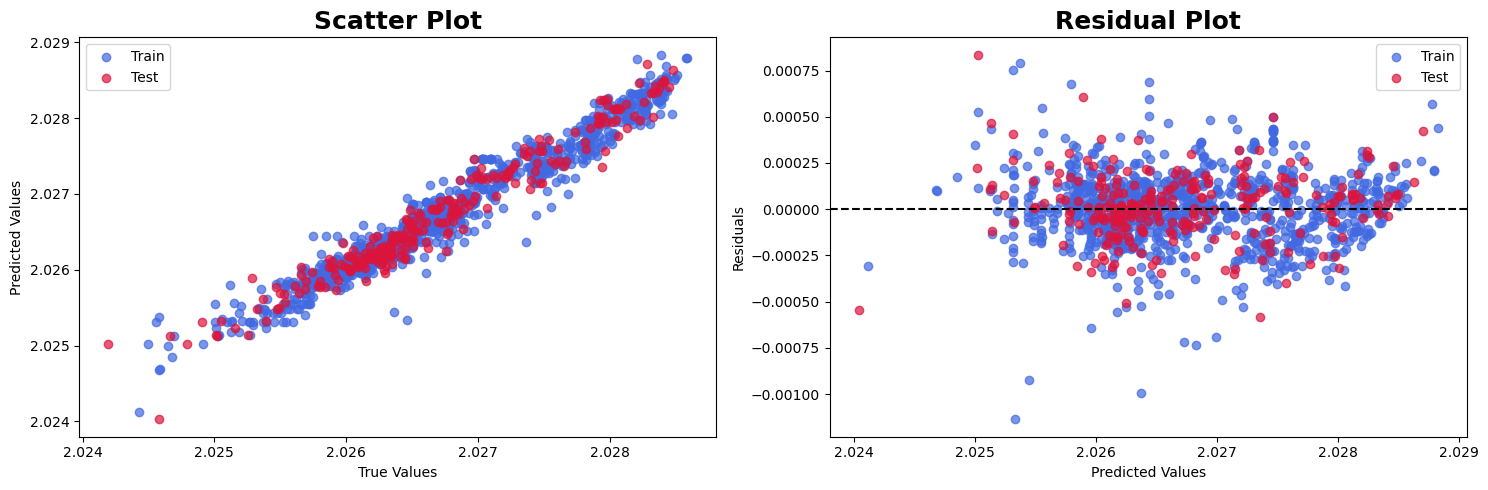

In [296]:
#Linear Regression Model
model_evaluation(LinearRegression())

------------------------------------------------------------------------------------------------------------------------
R² Score               : 0.9501
Adjusted R² Score      : 0.9499
Mean Absolute Error    : 0.0001
Mean Squared Error     : 0.0000
Root Mean Squared Error: 0.0002
Mean Percentage Error  : -0.00%
MAPE                   : 0.01%
------------------------------------------------------------------------------------------------------------------------


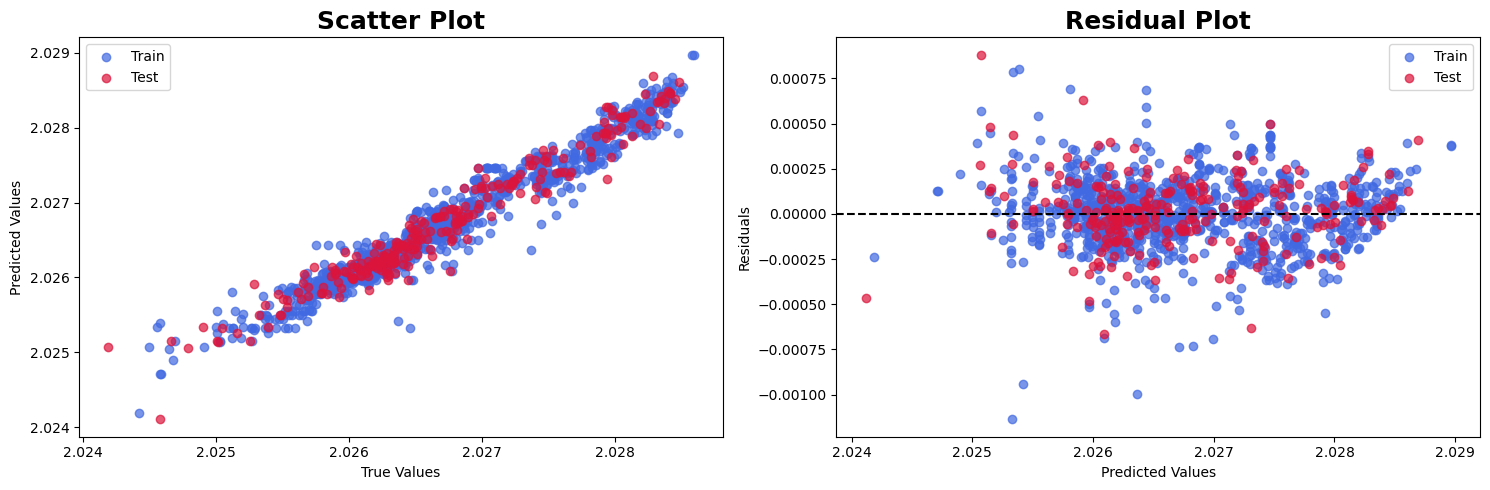

In [299]:
#RidgeCV Regression Model
model_evaluation(RidgeCV())

------------------------------------------------------------------------------------------------------------------------
R² Score               : 0.9397
Adjusted R² Score      : 0.9394
Mean Absolute Error    : 0.0001
Mean Squared Error     : 0.0000
Root Mean Squared Error: 0.0002
Mean Percentage Error  : -0.00%
MAPE                   : 0.01%
------------------------------------------------------------------------------------------------------------------------


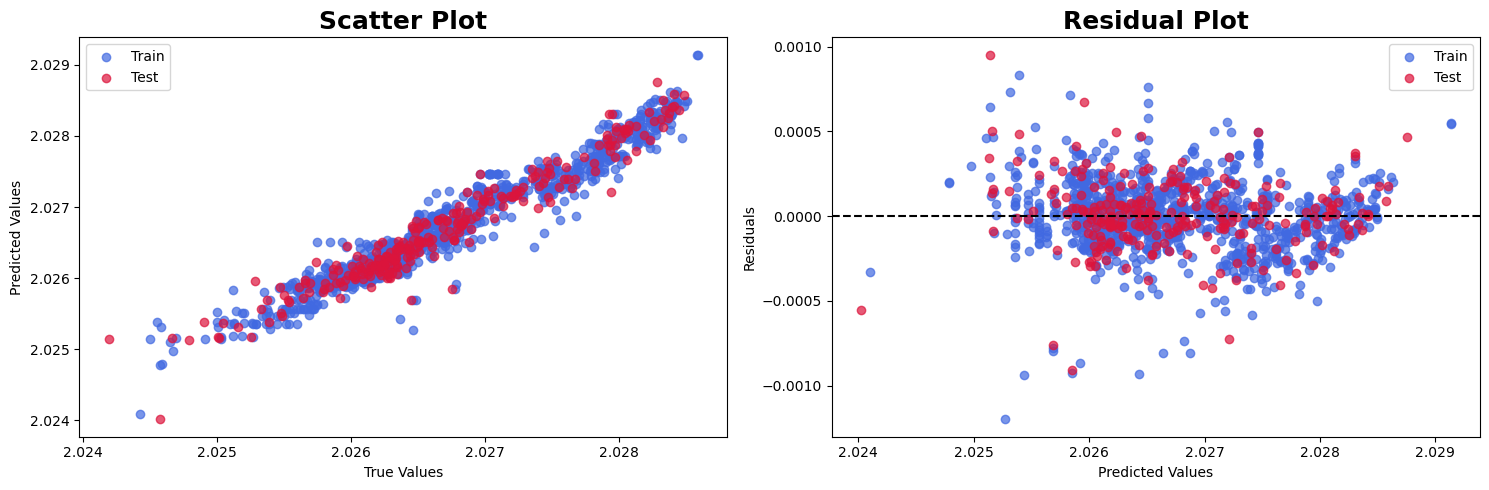

In [300]:
#LassoCV Regression Model
model_evaluation(LassoCV())

------------------------------------------------------------------------------------------------------------------------
R² Score               : 0.9397
Adjusted R² Score      : 0.9394
Mean Absolute Error    : 0.0001
Mean Squared Error     : 0.0000
Root Mean Squared Error: 0.0002
Mean Percentage Error  : -0.00%
MAPE                   : 0.01%
------------------------------------------------------------------------------------------------------------------------


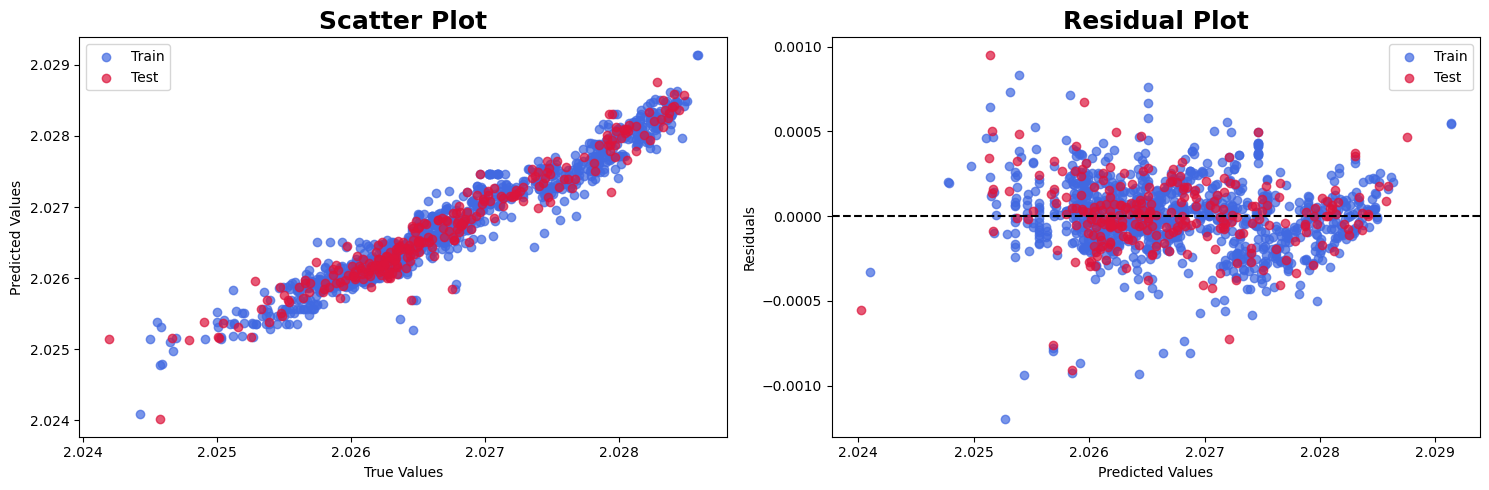

In [301]:
#ElasticNetCV Regression Model
model_evaluation(ElasticNetCV())

------------------------------------------------------------------------------------------------------------------------
R² Score               : 0.9639
Adjusted R² Score      : 0.9637
Mean Absolute Error    : 0.0001
Mean Squared Error     : 0.0000
Root Mean Squared Error: 0.0002
Mean Percentage Error  : -0.00%
MAPE                   : 0.01%
------------------------------------------------------------------------------------------------------------------------


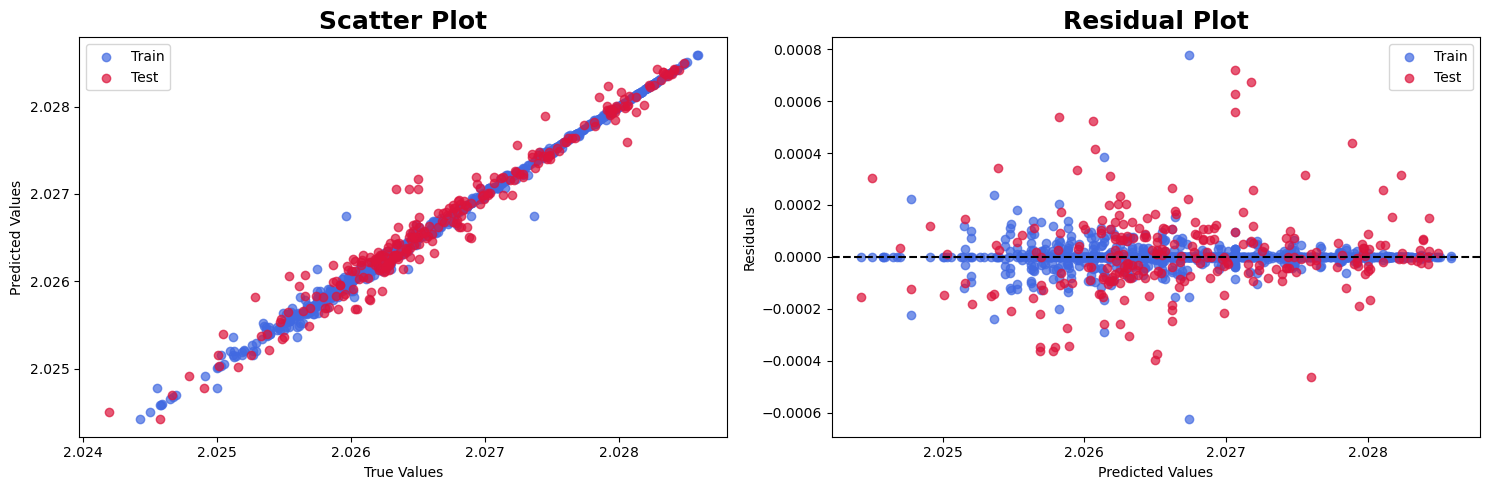

In [302]:
#DecisionTree Regressor Model
model_evaluation(DecisionTreeRegressor())

------------------------------------------------------------------------------------------------------------------------
R² Score               : 0.9805
Adjusted R² Score      : 0.9804
Mean Absolute Error    : 0.0001
Mean Squared Error     : 0.0000
Root Mean Squared Error: 0.0001
Mean Percentage Error  : -0.00%
MAPE                   : 0.00%
------------------------------------------------------------------------------------------------------------------------


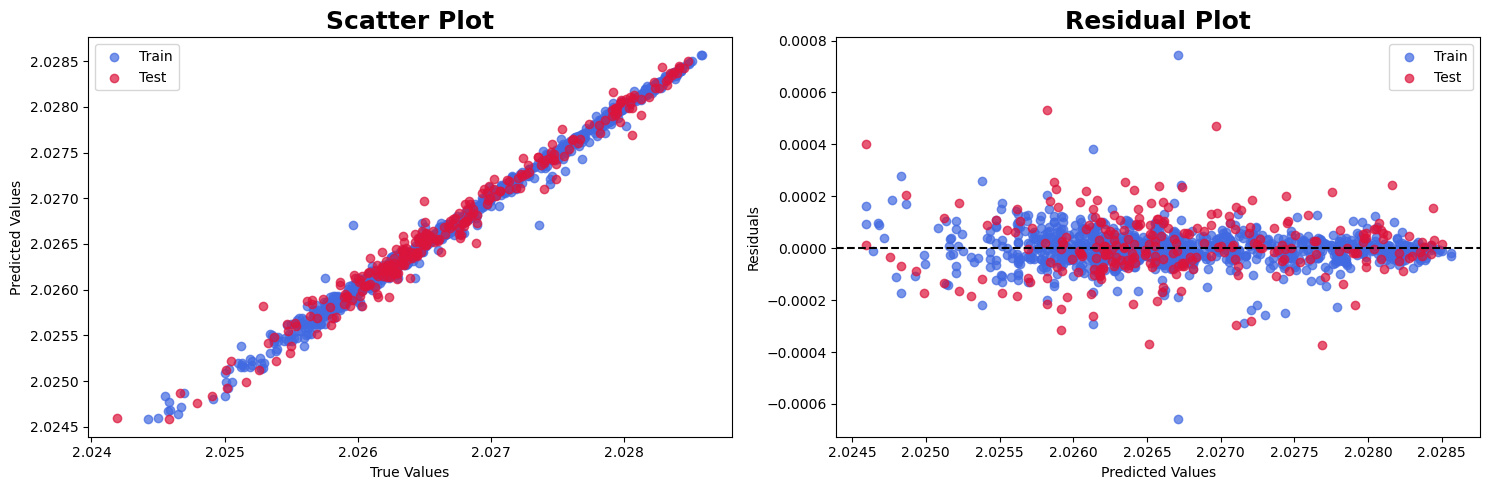

In [303]:
#Random Forest Regressor Model
model_evaluation(RandomForestRegressor())

------------------------------------------------------------------------------------------------------------------------
R² Score               : 0.9735
Adjusted R² Score      : 0.9734
Mean Absolute Error    : 0.0001
Mean Squared Error     : 0.0000
Root Mean Squared Error: 0.0001
Mean Percentage Error  : -0.00%
MAPE                   : 0.00%
------------------------------------------------------------------------------------------------------------------------


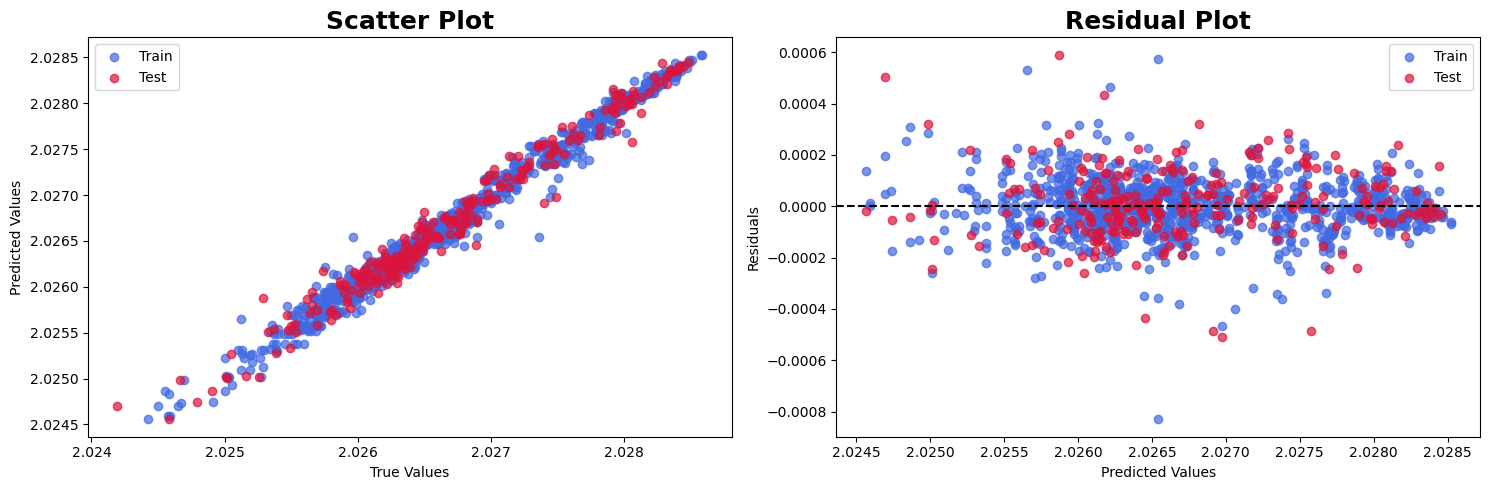

In [304]:
#Gradient Boosting Regressor Model
model_evaluation(GradientBoostingRegressor())

------------------------------------------------------------------------------------------------------------------------
R² Score               : 0.9577
Adjusted R² Score      : 0.9576
Mean Absolute Error    : 0.0001
Mean Squared Error     : 0.0000
Root Mean Squared Error: 0.0002
Mean Percentage Error  : -0.00%
MAPE                   : 0.01%
------------------------------------------------------------------------------------------------------------------------


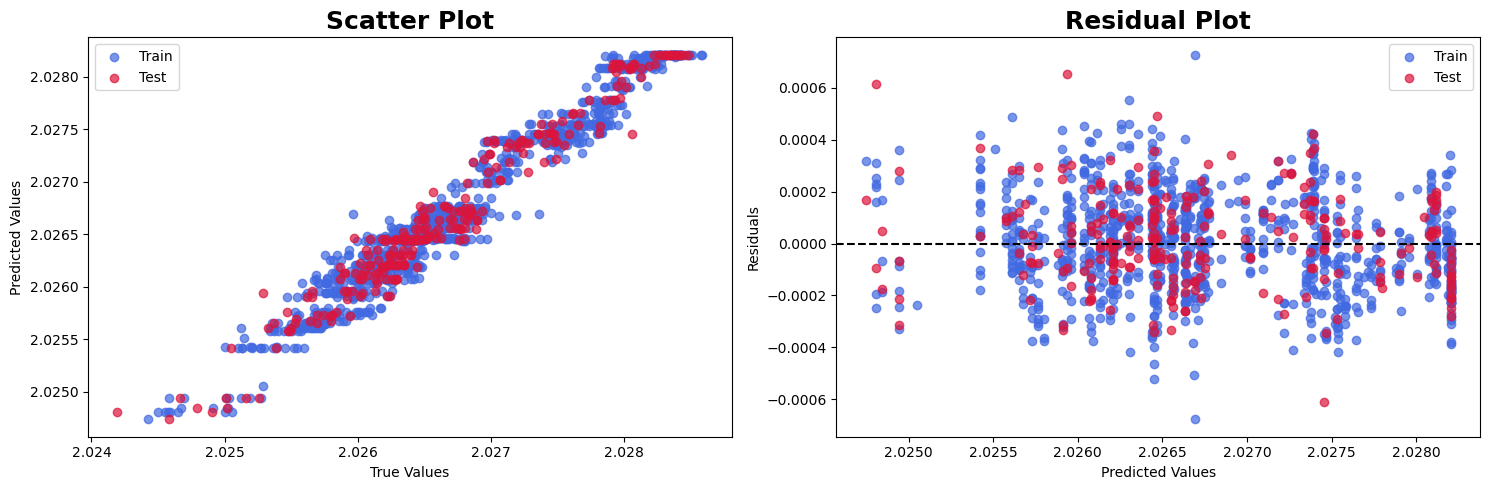

In [305]:
#AdaBoost Regressor Model
model_evaluation(AdaBoostRegressor())

------------------------------------------------------------------------------------------------------------------------
R² Score               : 0.9591
Adjusted R² Score      : 0.9590
Mean Absolute Error    : 0.0001
Mean Squared Error     : 0.0000
Root Mean Squared Error: 0.0002
Mean Percentage Error  : -0.00%
MAPE                   : 0.01%
------------------------------------------------------------------------------------------------------------------------


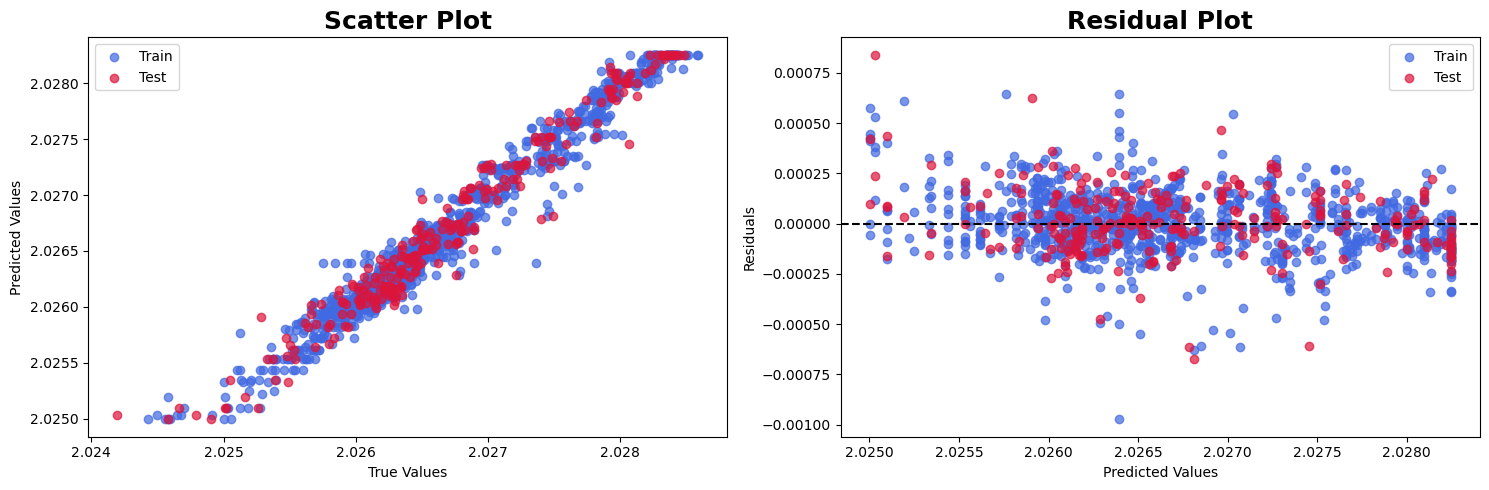

In [306]:
#XGBRegressor Model
model_evaluation(XGBRegressor())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000526 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1971
[LightGBM] [Info] Number of data points in the train set: 1020, number of used features: 40
[LightGBM] [Info] Start training from score 2.026759
------------------------------------------------------------------------------------------------------------------------
R² Score               : 0.9806
Adjusted R² Score      : 0.9806
Mean Absolute Error    : 0.0001
Mean Squared Error     : 0.0000
Root Mean Squared Error: 0.0001
Mean Percentage Error  : -0.00%
MAPE                   : 0.00%
------------------------------------------------------------------------------------------------------------------------


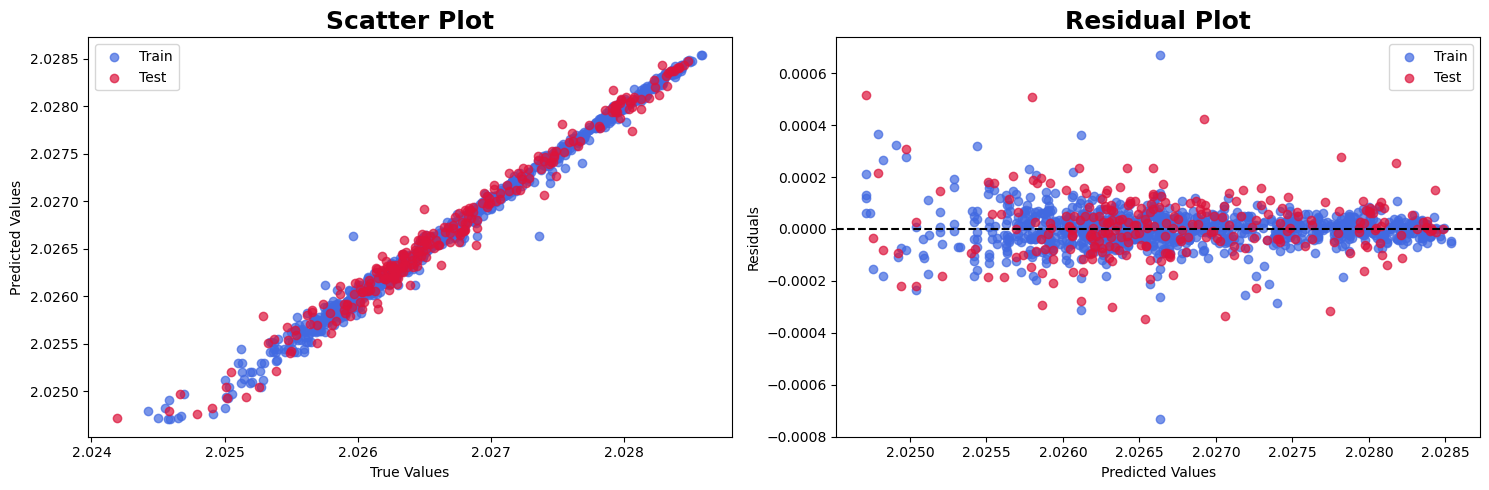

In [307]:
#LGBM Regressor Model
model_evaluation(LGBMRegressor())

------------------------------------------------------------------------------------------------------------------------
R² Score               : 0.9820
Adjusted R² Score      : 0.9820
Mean Absolute Error    : 0.0001
Mean Squared Error     : 0.0000
Root Mean Squared Error: 0.0001
Mean Percentage Error  : -0.00%
MAPE                   : 0.00%
------------------------------------------------------------------------------------------------------------------------


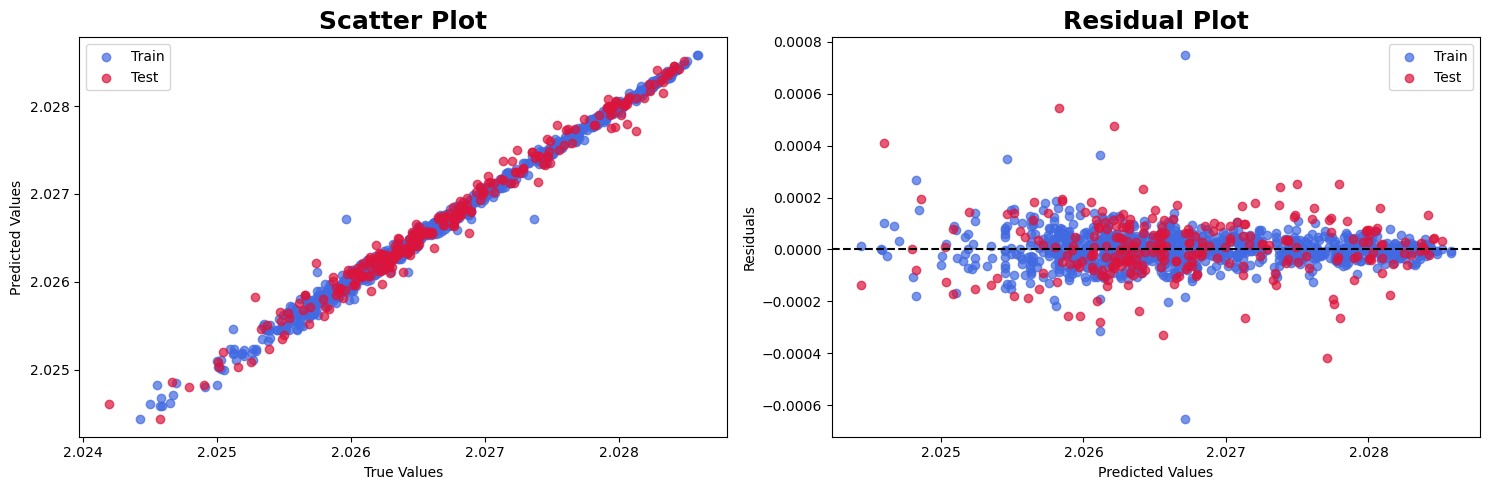

In [308]:
#CatBoost Regressor Model
model_evaluation(CatBoostRegressor(verbose=0))

In [ ]:
##Model's Performance Comparison 

In [309]:
algos = ["Linear Regression","RidgeCV Regression","LassoCV Regression","ElasticNet Regression","DecisionTree Regressor",
         "RandomForest Regressor","GradientBoosting Regressor","AdaBoost Regressor","XGBoost Regressor","LGBM Regressor",
         "CatBoost Regressor"]

In [310]:
performance = pd.DataFrame({"Model":algos,"R2_Score":r2score,"Adjusted_R2":adj_r2_score,"MAE":mae_score,
                           "MSE":mse_score,"RMSE":rmse_score,"MPE":mpe_score,"MAPE":mape_score})

In [311]:
performance

,Model,R2_Score,Adjusted_R2,MAE,MSE,RMSE,MPE,MAPE
0,Linear Regression,0.953375,0.953191,0.000138,3.449331e-08,0.000186,-0.000692,0.006818
1,RidgeCV Regression,0.950114,0.949918,0.000141,3.690565e-08,0.000192,-0.000670,0.006979
2,LassoCV Regression,0.939681,0.939444,0.000149,4.462395e-08,0.000211,-0.000413,0.007359
3,ElasticNet Regression,0.939682,0.939444,0.000149,4.462350e-08,0.000211,-0.000413,0.007359
4,DecisionTree Regressor,0.963868,0.963726,0.000110,2.673046e-08,0.000163,-0.000646,0.005444
5,RandomForest Regressor,0.980474,0.980397,0.000087,1.444515e-08,0.000120,-0.000407,0.004309
6,GradientBoosting Regressor,0.973477,0.973373,0.000101,1.962153e-08,0.000140,-0.000459,0.004994
7,AdaBoost Regressor,0.957726,0.957560,0.000139,3.127424e-08,0.000177,-0.000667,0.006851
8,XGBoost Regressor,0.959141,0.958980,0.000127,3.022721e-08,0.000174,-0.000642,0.006267
9,LGBM Regressor,0.980629,0.980552,0.000087,1.433094e-08,0.000120,-0.000465,0.004301


In [312]:
#Creating Stacked Model 

In [313]:
lgbm = LGBMRegressor()
rf = RandomForestRegressor()
catboost = CatBoostRegressor(verbose=0)
gb = GradientBoostingRegressor()
xgb = XGBRegressor()

In [314]:
estimators = [('lgbm', lgbm),('rf', rf),('catboost', catboost),('gb', gb),('xgb', xgb)]

In [315]:
stacked_model = StackingRegressor(estimators=estimators, final_estimator=LGBMRegressor(),verbose=0)

stacked_model.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000503 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1971
[LightGBM] [Info] Number of data points in the train set: 1020, number of used features: 40
[LightGBM] [Info] Start training from score 2.026759
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 816, number of used features: 40
[LightGBM] [Info] Start training from score 2.026762
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

,estimators,"[('lgbm', ...), ('rf', ...), ...]"
,final_estimator,LGBMRegressor()
,cv,None
,n_jobs,None
,passthrough,False
,verbose,0
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100


In [316]:
y_pred = stacked_model.predict(x_test)

In [317]:
n = len(y)
k = X.shape[1]

r2 = r2_score(y_test, y_pred)
adj_r2 = 1 - ((1-r2)*(n-1)/(n-k-1))
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
mpe = np.mean((y_test - y_pred) / y_test) * 100
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100    

In [318]:
print("R-squared:", r2)
print("Adjusted R-Squared",adj_r2)
print()
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Percentage Error (MPE):", mpe)
print("Mean Absolute Percentage Error (MAPE):", mape)

R-squared: 0.9759563489241943
Adjusted R-Squared 0.9749545301293691

Mean Absolute Error (MAE): 9.539700605150185e-05
Mean Squared Error (MSE): 1.7787476362522252e-08
Root Mean Squared Error (RMSE): 0.0001333696980671481
Mean Percentage Error (MPE): -0.0008065857915022316
Mean Absolute Percentage Error (MAPE): 0.004707558275349802
